# Experiment 1.3: Statistical Analysis

**Rigorous statistical comparison of learning algorithms** following Demsar (2006), Garcia & Herrera (2008), and Benavoli et al. (2016).

## Methodology

### Frequentist Analysis (Demsar 2006; Garcia & Herrera 2008)
1. **Rank** algorithms within each dataset (using dataset-level means across 5 CV folds)
2. **Friedman test** with Iman-Davenport correction (omnibus: are there *any* differences?)
3. **Post-hoc — Nemenyi test**: All-vs-all pairwise comparison via Critical Difference (CD)
4. **Post-hoc — Wilcoxon signed-rank** tests with Holm step-down correction (more powerful than Nemenyi)

### Effect Size Analysis
5. **Vargha-Delaney A** measure (non-parametric effect size, probability of superiority)
6. **Cliff's delta** (related to A: δ = 2A − 1)
7. **Win / Draw / Loss** counts per method pair

### Additional Analyses
8. **PAMA** — Probability of Achieving Maximum Accuracy (Delgado et al. 2014) — fold-level
9. **Rank distribution** analysis per method (boxplots, violin plots)
10. **Bootstrap confidence intervals** on average ranks
11. **Pairwise scatter plots** for key method comparisons

### Visualizations
- Critical Difference diagrams (all methods, top 10, top 5)
- Significance heatmap (Holm-corrected p-values)
- Effect size heatmap (Vargha-Delaney A)
- Win/Draw/Loss heatmap
- Rank distribution violin/box plots
- PAMA bar charts

**Unit of observation** for statistical tests: one dataset (mean across 5 CV folds).
**Unit of observation** for PAMA: one fold (dataset × fold).
All results use **HPO** (tuned hyperparameters).

---

**Structure:**
- **Section 1:** PD (Probability of Default) — AUC
- **Section 2:** LGD (Loss Given Default) — R²

## 1. Setup & Configuration

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import friedmanchisquare, wilcoxon, rankdata, chi2, mannwhitneyu
from scipy.stats import f as f_dist
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
import math

# Setup paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.methods.method_config import FOUNDATION_METHODS

EXPERIMENT_NAME = "experiment1"
RESULTS_DIR = PROJECT_ROOT / "results" / EXPERIMENT_NAME
SUMMARY_DIR = RESULTS_DIR / "summary"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("  EXPERIMENT 1.3: STATISTICAL ANALYSIS")
print("  Following Demsar (2006), Garcia & Herrera (2008)")
print("=" * 80)
print(f"Project root:  {PROJECT_ROOT}")
print(f"Results dir:   {RESULTS_DIR}")
print(f"Figures dir:   {FIGURES_DIR}")

# Generate summaries if needed
if SUMMARY_DIR.exists() and any(SUMMARY_DIR.glob("*.csv")):
    print("\nSummary files present.")
else:
    print("\nGenerating summaries...")
    from src.utils.summarize_results import summarize_results
    summarize_results(experiment=EXPERIMENT_NAME)

print("\nSetup complete.")

  EXPERIMENT 1.3: STATISTICAL ANALYSIS
  Following Demsar (2006), Garcia & Herrera (2008)
Project root:  c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit
Results dir:   c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1
Figures dir:   c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1\figures

Summary files present.

Setup complete.


In [2]:
# =============================================================================
# FONT & STYLE CONFIGURATION
# =============================================================================
FONT_SCALE = 1.5

plt.rcParams['figure.figsize'] = (20, 10)
plt.rcParams['figure.dpi'] = 96
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.size'] = FONT_SCALE * 11
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = FONT_SCALE * 15
plt.rcParams['axes.labelsize'] = FONT_SCALE * 12
plt.rcParams['xtick.labelsize'] = FONT_SCALE * 12
plt.rcParams['ytick.labelsize'] = FONT_SCALE * 10
sns.set_style('whitegrid')
sns.set_palette('Set2')

FS_TITLE = FONT_SCALE * 16
FS_SUBTITLE = FONT_SCALE * 14
FS_AXIS_LABEL = FONT_SCALE * 12
FS_TICK = FONT_SCALE * 9
FS_TICK_Y = FONT_SCALE * 10
FS_ANNOT = FONT_SCALE * 7
FS_LEGEND = FONT_SCALE * 10
FS_BAR_LABEL = FONT_SCALE * 9
FS_SUPTITLE = FONT_SCALE * 16

## 2. Data Loading

In [3]:
pd_raw = pd.read_csv(SUMMARY_DIR / "summary_pd_raw.csv")
lgd_raw = pd.read_csv(SUMMARY_DIR / "summary_lgd_raw.csv")

print("Data loaded:")
print(f"  PD:  {len(pd_raw)} fold-results, {pd_raw['method'].nunique()} methods, {pd_raw['dataset'].nunique()} datasets")
print(f"  LGD: {len(lgd_raw)} fold-results, {lgd_raw['method'].nunique()} methods, {lgd_raw['dataset'].nunique()} datasets")
print(f"  PD methods:  {sorted(pd_raw['method'].unique())}")
print(f"  LGD methods: {sorted(lgd_raw['method'].unique())}")

Data loaded:
  PD:  4350 fold-results, 29 methods, 15 datasets
  LGD: 1540 fold-results, 22 methods, 7 datasets
  PD methods:  ['LogReg', 'NCM', 'NaiveBayes', 'RandomForest', 'amformer', 'autoint', 'catboost', 'danets', 'dcn2', 'excelformer', 'ftt', 'knn', 'lightgbm', 'mitra', 'mlp', 'mlp_plr', 'realmlp', 'snn', 'svm', 'switchtab', 't2gformer', 'tabicl', 'tabm', 'tabnet', 'tabpfn', 'tabpfn_real', 'tabpfn_v2', 'tangos', 'xgboost']
  LGD methods: ['LinearRegression', 'RandomForest', 'autoint', 'catboost', 'dcn2', 'excelformer', 'ftt', 'knn', 'lightgbm', 'mlp', 'mlp_plr', 'modernNCA', 'ptarl', 'realmlp', 'resnet', 'svm', 't2gformer', 'tabm', 'tabnet', 'tabpfn_v2', 'tangos', 'xgboost']


## 3. Statistical Helper Functions

In [4]:
# =============================================================================
# STATISTICAL ANALYSIS FUNCTIONS
# Following Demsar (2006), Garcia & Herrera (2008), Benavoli et al. (2016)
# =============================================================================

# ---------------------------------------------------------------------------
# 1. Data preparation
# ---------------------------------------------------------------------------

def compute_dataset_performance(raw_df, metric, hpo_mode='HPO'):
    """Dataset x method matrix: mean performance across 5 CV folds per dataset."""
    df = raw_df[raw_df['hpo_mode'] == hpo_mode].copy()
    if metric not in df.columns:
        return None
    pivot = df.pivot_table(index='dataset', columns='method', values=metric, aggfunc='mean')
    return pivot.dropna(axis=1)


def compute_foldlevel_performance(raw_df, metric, hpo_mode='HPO'):
    """(Dataset x fold) x method matrix for fold-level analyses (PAMA)."""
    df = raw_df[raw_df['hpo_mode'] == hpo_mode].copy()
    if metric not in df.columns:
        return None
    pivot = df.pivot_table(index=['dataset', 'fold_id'], columns='method', values=metric)
    return pivot.dropna(axis=1)


def compute_ranks(perf_matrix, higher_is_better=True):
    """Rank methods per row. 1 = best."""
    return perf_matrix.rank(axis=1, ascending=not higher_is_better, method='average')


# ---------------------------------------------------------------------------
# 2. Friedman + Iman-Davenport (Demsar 2006, Sec 3.2)
# ---------------------------------------------------------------------------

def friedman_iman_davenport(perf_matrix, higher_is_better=True):
    """
    Friedman test with Iman-Davenport correction.

    The original Friedman statistic (chi2_F) is conservative. The Iman-Davenport
    correction (F_F) follows an F-distribution and has better power.

    Returns: (chi2_F, F_F, p_friedman, p_iman_davenport, N, k)
    """
    ranks = compute_ranks(perf_matrix, higher_is_better)
    N = ranks.shape[0]  # number of datasets
    k = ranks.shape[1]  # number of methods
    avg_ranks = ranks.mean(axis=0)

    # Friedman statistic (Eq. 1 in Demsar)
    chi2_F = (12 * N / (k * (k + 1))) * (
        (avg_ranks ** 2).sum() - k * (k + 1) ** 2 / 4
    )
    # Iman-Davenport correction (Eq. 2 in Demsar)
    F_F = ((N - 1) * chi2_F) / (N * (k - 1) - chi2_F)
    p_friedman = 1 - chi2.cdf(chi2_F, k - 1)
    p_iman = 1 - f_dist.cdf(F_F, k - 1, (k - 1) * (N - 1))
    return chi2_F, F_F, p_friedman, p_iman, N, k


# ---------------------------------------------------------------------------
# 3. Nemenyi Critical Difference (Demsar 2006, Eq. 7)
# ---------------------------------------------------------------------------

# Critical values q_alpha for the Studentized range statistic / sqrt(2)
# From Demsar (2006), Table 5, alpha=0.05
Q_ALPHA_005 = {
    2: 1.960, 3: 2.344, 4: 2.569, 5: 2.728,
    6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102,
    10: 3.164, 11: 3.219, 12: 3.268, 13: 3.313,
    14: 3.354, 15: 3.391, 16: 3.426, 17: 3.458,
    18: 3.489, 19: 3.517, 20: 3.544, 21: 3.569,
    22: 3.593, 23: 3.616, 24: 3.637, 25: 3.658,
    26: 3.678, 27: 3.696, 28: 3.714, 29: 3.732,
    30: 3.749,
}
# alpha=0.10
Q_ALPHA_010 = {
    2: 1.645, 3: 2.052, 4: 2.291, 5: 2.460,
    6: 2.589, 7: 2.693, 8: 2.780, 9: 2.855,
    10: 2.920, 11: 2.978, 12: 3.030, 13: 3.077,
    14: 3.120, 15: 3.159, 16: 3.196, 17: 3.230,
    18: 3.261, 19: 3.291, 20: 3.319, 21: 3.345,
    22: 3.370, 23: 3.394, 24: 3.416, 25: 3.437,
    26: 3.457, 27: 3.476, 28: 3.495, 29: 3.513,
    30: 3.530,
}

def nemenyi_cd(k, N, alpha=0.05):
    """CD = q_alpha * sqrt(k(k+1) / (6N))"""
    table = Q_ALPHA_005 if alpha == 0.05 else Q_ALPHA_010
    if k in table:
        q = table[k]
    else:
        from scipy.stats import norm
        q = norm.ppf(1 - alpha / (k * (k - 1)))
    return q * np.sqrt(k * (k + 1) / (6 * N))


# ---------------------------------------------------------------------------
# 4. Pairwise Wilcoxon signed-rank + Holm (Demsar 2006, Sec 3.3)
# ---------------------------------------------------------------------------

def pairwise_wilcoxon_holm(perf_matrix):
    """
    Pairwise Wilcoxon signed-rank tests with Holm step-down correction.
    More powerful than Nemenyi because it uses actual performance values,
    not just ranks, and Holm is uniformly more powerful than Bonferroni.
    """
    methods = list(perf_matrix.columns)
    results = []
    for ma, mb in combinations(methods, 2):
        diff = perf_matrix[ma] - perf_matrix[mb]
        if (diff == 0).all():
            results.append({'method_a': ma, 'method_b': mb, 'stat': np.nan, 'p_raw': 1.0})
            continue
        try:
            stat, p_raw = wilcoxon(perf_matrix[ma], perf_matrix[mb],
                                   alternative='two-sided', zero_method='wilcox')
        except ValueError:
            results.append({'method_a': ma, 'method_b': mb, 'stat': np.nan, 'p_raw': 1.0})
            continue
        results.append({'method_a': ma, 'method_b': mb, 'stat': stat, 'p_raw': p_raw})

    if not results:
        return pd.DataFrame()
    res_df = pd.DataFrame(results)
    reject, p_corrected, _, _ = multipletests(res_df['p_raw'], alpha=0.05, method='holm')
    res_df['p_corrected'] = p_corrected
    res_df['significant'] = reject
    return res_df


# ---------------------------------------------------------------------------
# 5. Effect sizes: Vargha-Delaney A & Cliff's delta
# ---------------------------------------------------------------------------

def vargha_delaney_a(x, y):
    """
    Vargha-Delaney A measure (A12): probability that a random observation
    from x is larger than a random observation from y.
    A = 0.5 means no effect. A > 0.5 means x tends to be larger.
    """
    nx, ny = len(x), len(y)
    r = rankdata(np.concatenate([x, y]))
    r1 = r[:nx].sum()
    return (r1 / nx - (nx + 1) / 2) / ny


def cliffs_delta(x, y):
    """Cliff's delta = 2A - 1. Ranges from -1 to +1."""
    return 2 * vargha_delaney_a(x, y) - 1


def a_effect_label(a_val):
    """Effect size label based on Vargha & Delaney (2000) thresholds."""
    d = abs(a_val - 0.5)
    if d < 0.06:
        return 'negligible'
    elif d < 0.14:
        return 'small'
    elif d < 0.21:
        return 'medium'
    else:
        return 'large'


def compute_all_effect_sizes(perf_matrix):
    """Compute pairwise Vargha-Delaney A for all method pairs."""
    methods = list(perf_matrix.columns)
    results = []
    for ma, mb in combinations(methods, 2):
        a_val = vargha_delaney_a(perf_matrix[ma].values, perf_matrix[mb].values)
        delta = 2 * a_val - 1
        results.append({
            'method_a': ma, 'method_b': mb,
            'A': a_val, 'cliffs_delta': delta,
            'effect': a_effect_label(a_val)
        })
    return pd.DataFrame(results)


# ---------------------------------------------------------------------------
# 6. Win / Draw / Loss
# ---------------------------------------------------------------------------

def compute_win_draw_loss(perf_matrix, tolerance=1e-6):
    """
    For each pair (A, B), count datasets where A > B (win), A ≈ B (draw), A < B (loss).
    """
    methods = list(perf_matrix.columns)
    results = []
    for ma, mb in combinations(methods, 2):
        diff = perf_matrix[ma] - perf_matrix[mb]
        wins = (diff > tolerance).sum()
        losses = (diff < -tolerance).sum()
        draws = len(diff) - wins - losses
        results.append({'method_a': ma, 'method_b': mb,
                        'wins': wins, 'draws': draws, 'losses': losses})
    return pd.DataFrame(results)


# ---------------------------------------------------------------------------
# 7. PAMA (Delgado et al. 2014)
# ---------------------------------------------------------------------------

def compute_pama(perf_matrix, higher_is_better=True):
    """PAMA: fraction of observations where each method achieves the best score."""
    if higher_is_better:
        best = perf_matrix.idxmax(axis=1)
    else:
        best = perf_matrix.idxmin(axis=1)
    counts = best.value_counts()
    for m in perf_matrix.columns:
        if m not in counts.index:
            counts[m] = 0
    return (counts / len(perf_matrix)).sort_values(ascending=False)


# ---------------------------------------------------------------------------
# 8. Bootstrap CI on average ranks
# ---------------------------------------------------------------------------

def bootstrap_rank_ci(perf_matrix, higher_is_better=True, n_boot=10000, alpha=0.05):
    """Bootstrap confidence intervals on average ranks (Demsar-style)."""
    N, k = perf_matrix.shape
    rng = np.random.RandomState(42)
    boot_avg_ranks = np.zeros((n_boot, k))
    for b in range(n_boot):
        idx = rng.choice(N, size=N, replace=True)
        boot_perf = perf_matrix.iloc[idx]
        boot_ranks = compute_ranks(boot_perf, higher_is_better)
        boot_avg_ranks[b] = boot_ranks.mean().values
    lo = np.percentile(boot_avg_ranks, 100 * alpha / 2, axis=0)
    hi = np.percentile(boot_avg_ranks, 100 * (1 - alpha / 2), axis=0)
    return pd.DataFrame({
        'method': perf_matrix.columns,
        'mean_rank': compute_ranks(perf_matrix, higher_is_better).mean().values,
        'ci_lower': lo, 'ci_upper': hi
    }).sort_values('mean_rank')


# ===========================================================================
# VISUALIZATION FUNCTIONS
# ===========================================================================

def plot_cd_diagram(avg_ranks, cd_value, pairwise_df, title, figsize=(18, 10),
                    alpha=0.05, foundation_methods=None, save_path=None):
    """Critical Difference diagram (Demsar 2006 style)."""
    if foundation_methods is None:
        foundation_methods = set()
    methods = list(avg_ranks.index)
    ranks = avg_ranks.values
    k = len(methods)

    fig, ax = plt.subplots(figsize=figsize)
    rank_min, rank_max = 1, k
    margin = 0.8
    ax.set_xlim(rank_min - margin, rank_max + margin)
    ax.set_ylim(-3, k + 2.5)

    # Rank axis at top
    ax.hlines(k + 0.3, rank_min, rank_max, color='black', linewidth=1.5)
    for r in range(1, k + 1):
        ax.vlines(r, k + 0.1, k + 0.5, color='black', linewidth=1)
        ax.text(r, k + 0.65, str(r), ha='center', va='bottom', fontsize=FS_TICK)

    # CD bar
    if cd_value is not None:
        cd_start = rank_min
        ax.hlines(k + 1.3, cd_start, cd_start + cd_value, color='red', linewidth=3)
        ax.text(cd_start + cd_value / 2, k + 1.55, f'CD = {cd_value:.2f}',
                ha='center', va='bottom', fontsize=FS_TICK * 1.1, color='red', fontweight='bold')

    # Place methods on left and right sides
    n_left = (k + 1) // 2
    n_right = k - n_left
    spacing_left = max(k / max(n_left, 1), 1.0)
    spacing_right = max(k / max(n_right, 1), 1.0)

    for i in range(n_left):
        y_pos = k - 0.5 - i * spacing_left
        rv = ranks[i]
        is_fm = methods[i] in foundation_methods
        col = 'red' if is_fm else 'black'
        wt = 'bold' if is_fm else 'normal'
        ax.hlines(y_pos, rank_min - margin + 0.1, rv, color='gray', linewidth=0.5)
        ax.plot(rv, y_pos, 'o', color=col, markersize=6, zorder=5)
        ax.text(rank_min - margin + 0.05, y_pos, f'{methods[i]} ({rv:.2f})',
                ha='right', va='center', fontsize=FS_TICK_Y, color=col, fontweight=wt)

    for j in range(n_right):
        i = n_left + j
        y_pos = k - 0.5 - j * spacing_right
        rv = ranks[i]
        is_fm = methods[i] in foundation_methods
        col = 'red' if is_fm else 'black'
        wt = 'bold' if is_fm else 'normal'
        ax.hlines(y_pos, rv, rank_max + margin - 0.1, color='gray', linewidth=0.5)
        ax.plot(rv, y_pos, 'o', color=col, markersize=6, zorder=5)
        ax.text(rank_max + margin - 0.05, y_pos, f'({rv:.2f}) {methods[i]}',
                ha='left', va='center', fontsize=FS_TICK_Y, color=col, fontweight=wt)

    # Clique bars (groups of non-significantly-different methods)
    if pairwise_df is not None and not pairwise_df.empty:
        nonsig = pairwise_df[~pairwise_df['significant']]
        rl = dict(zip(methods, ranks))
        bars = []
        for _, row in nonsig.iterrows():
            ra = rl.get(row['method_a'])
            rb = rl.get(row['method_b'])
            if ra is not None and rb is not None:
                bars.append((min(ra, rb), max(ra, rb)))
        if bars:
            bars.sort()
            merged = [bars[0]]
            for s, e in bars[1:]:
                if s <= merged[-1][1] + 0.01:
                    merged[-1] = (merged[-1][0], max(merged[-1][1], e))
                else:
                    merged.append((s, e))
            bar_y = -0.5
            for s, e in merged:
                ax.hlines(bar_y, s - 0.05, e + 0.05, color='black', linewidth=4)
                bar_y -= 0.45

    ax.set_title(title, fontsize=FS_TITLE, fontweight='bold', pad=45)
    ax.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_significance_heatmap(pairwise_df, avg_ranks, title, save_path=None):
    """Heatmap of Holm-corrected Wilcoxon p-values (ordered by avg rank)."""
    methods = list(avg_ranks.index)
    n = len(methods)
    p_matrix = pd.DataFrame(np.nan, index=methods, columns=methods)
    for _, row in pairwise_df.iterrows():
        if row['method_a'] in methods and row['method_b'] in methods:
            p_matrix.loc[row['method_a'], row['method_b']] = row['p_corrected']
            p_matrix.loc[row['method_b'], row['method_a']] = row['p_corrected']
    np.fill_diagonal(p_matrix.values, 1.0)

    fig, ax = plt.subplots(figsize=(max(14, n * 0.55), max(12, n * 0.5)))
    annot = p_matrix.copy().astype(str)
    for i in range(n):
        for j in range(n):
            v = p_matrix.iloc[i, j]
            if i == j:
                annot.iloc[i, j] = '\u2014'
            elif pd.isna(v):
                annot.iloc[i, j] = ''
            elif v < 0.001:
                annot.iloc[i, j] = '<.001***'
            elif v < 0.01:
                annot.iloc[i, j] = f'{v:.2f}**'
            elif v < 0.05:
                annot.iloc[i, j] = f'{v:.2f}*'
            else:
                annot.iloc[i, j] = f'{v:.2f}'

    sns.heatmap(p_matrix.astype(float), ax=ax, annot=annot, fmt='',
                cmap='RdYlGn', vmin=0, vmax=0.1, center=0.05,
                linewidths=0.5, linecolor='white',
                annot_kws={'fontsize': max(5, FS_ANNOT * 0.8)},
                cbar_kws={'label': 'Holm-corrected p-value'})
    ax.set_title(title, fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=FS_TICK * 0.9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=FS_TICK * 0.9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_effect_size_heatmap(effect_df, avg_ranks, title, save_path=None):
    """Heatmap of Vargha-Delaney A effect sizes (ordered by avg rank)."""
    methods = list(avg_ranks.index)
    n = len(methods)
    a_matrix = pd.DataFrame(0.5, index=methods, columns=methods)
    for _, row in effect_df.iterrows():
        ma, mb = row['method_a'], row['method_b']
        if ma in methods and mb in methods:
            a_matrix.loc[ma, mb] = row['A']
            a_matrix.loc[mb, ma] = 1 - row['A']  # symmetric complement

    fig, ax = plt.subplots(figsize=(max(14, n * 0.55), max(12, n * 0.5)))
    annot_arr = np.empty((n, n), dtype=object)
    for i in range(n):
        for j in range(n):
            v = a_matrix.iloc[i, j]
            if i == j:
                annot_arr[i, j] = '\u2014'
            else:
                lbl = a_effect_label(v)
                annot_arr[i, j] = f'{v:.2f}\n({lbl[0].upper()})'

    norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)
    sns.heatmap(a_matrix.astype(float), ax=ax, annot=annot_arr, fmt='',
                cmap='RdBu_r', norm=norm,
                linewidths=0.5, linecolor='white',
                annot_kws={'fontsize': max(4, FS_ANNOT * 0.7)},
                cbar_kws={'label': 'Vargha-Delaney A (row > col)'})
    ax.set_title(title, fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=FS_TICK * 0.9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=FS_TICK * 0.9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_wdl_heatmap(wdl_df, avg_ranks, title, N, save_path=None):
    """Win/Draw/Loss heatmap (ordered by avg rank)."""
    methods = list(avg_ranks.index)
    n = len(methods)
    wdl_matrix = pd.DataFrame(0.0, index=methods, columns=methods)
    annot_arr = np.empty((n, n), dtype=object)

    wdl_lookup = {}
    for _, row in wdl_df.iterrows():
        wdl_lookup[(row['method_a'], row['method_b'])] = (row['wins'], row['draws'], row['losses'])
        wdl_lookup[(row['method_b'], row['method_a'])] = (row['losses'], row['draws'], row['wins'])

    for i, ma in enumerate(methods):
        for j, mb in enumerate(methods):
            if i == j:
                wdl_matrix.iloc[i, j] = 0
                annot_arr[i, j] = '\u2014'
            elif (ma, mb) in wdl_lookup:
                w, d, l = wdl_lookup[(ma, mb)]
                wdl_matrix.iloc[i, j] = (w - l) / N  # net win rate
                annot_arr[i, j] = f'{w}/{d}/{l}'

    fig, ax = plt.subplots(figsize=(max(14, n * 0.55), max(12, n * 0.5)))
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    sns.heatmap(wdl_matrix.astype(float), ax=ax, annot=annot_arr, fmt='',
                cmap='RdBu_r', norm=norm,
                linewidths=0.5, linecolor='white',
                annot_kws={'fontsize': max(4, FS_ANNOT * 0.7)},
                cbar_kws={'label': 'Net win rate (row vs col)'})
    ax.set_title(title + f'\n(W/D/L counts, {N} datasets)', fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=FS_TICK * 0.9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=FS_TICK * 0.9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_rank_distributions(ranks_matrix, avg_ranks, title, foundation_methods=None, save_path=None):
    """Violin + strip plot of rank distributions, ordered by avg rank."""
    if foundation_methods is None:
        foundation_methods = set()
    order = list(avg_ranks.index)
    df_long = ranks_matrix[order].melt(var_name='Method', value_name='Rank')

    fig, ax = plt.subplots(figsize=(max(16, len(order) * 0.6), 8))
    sns.violinplot(data=df_long, x='Method', y='Rank', order=order, palette='Set2',
                   inner=None, alpha=0.4, ax=ax, cut=0)
    sns.stripplot(data=df_long, x='Method', y='Rank', order=order,
                  color='black', alpha=0.5, size=3, jitter=0.2, ax=ax)

    # Mark medians
    for i, m in enumerate(order):
        med = ranks_matrix[m].median()
        ax.plot(i, med, 'D', color='white', markersize=7, zorder=10, markeredgecolor='black')

    ax.set_xticklabels(order, rotation=45, ha='right', fontsize=FS_TICK)
    for label in ax.get_xticklabels():
        if label.get_text() in foundation_methods:
            label.set_color('red')
            label.set_fontweight('bold')
    ax.set_ylabel('Rank (1 = best)', fontsize=FS_AXIS_LABEL)
    ax.set_title(title, fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.invert_yaxis()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_bootstrap_ci(boot_df, title, foundation_methods=None, save_path=None):
    """Horizontal bar chart of average ranks with bootstrap 95% CIs."""
    if foundation_methods is None:
        foundation_methods = set()
    boot_df = boot_df.sort_values('mean_rank')

    fig, ax = plt.subplots(figsize=(12, max(6, len(boot_df) * 0.4)))
    y = np.arange(len(boot_df))
    xerr = np.array([boot_df['mean_rank'] - boot_df['ci_lower'],
                     boot_df['ci_upper'] - boot_df['mean_rank']])
    colors = ['#e74c3c' if m in foundation_methods else '#3498db' for m in boot_df['method']]

    ax.barh(y, boot_df['mean_rank'], xerr=xerr, color=colors, alpha=0.8,
            edgecolor='black', linewidth=0.5, capsize=4, height=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(boot_df['method'], fontsize=FS_TICK_Y)
    ax.set_xlabel('Average Rank (95% Bootstrap CI)', fontsize=FS_AXIS_LABEL)
    ax.set_title(title, fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

    legend_elements = [mpatches.Patch(facecolor='#e74c3c', label='Foundation Model'),
                       mpatches.Patch(facecolor='#3498db', label='Other')]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=FS_LEGEND)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_pama(win_fractions, title, foundation_methods=None, figsize=(14, 8), save_path=None):
    """PAMA bar chart with RdYlGn colormap, foundation model labels in red."""
    if foundation_methods is None:
        foundation_methods = set()
    data = win_fractions[win_fractions > 0]
    if len(data) == 0:
        data = win_fractions.head(5)
    data = data.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(data))
    bars = ax.bar(x, data.values * 100, alpha=0.85, edgecolor='black', linewidth=1.2)
    norm_c = plt.Normalize(vmin=0, vmax=max(data.max() * 100, 1))
    colors = plt.cm.RdYlGn(norm_c(data.values * 100))
    for bar, color in zip(bars, colors):
        bar.set_facecolor(color)

    ax.set_xticks(x)
    ax.set_xticklabels(data.index, rotation=45, ha='right', fontsize=FS_TICK)
    for label in ax.get_xticklabels():
        if label.get_text() in foundation_methods:
            label.set_color('red')
            label.set_fontweight('bold')
    ax.set_ylabel('Win Rate (%)', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_title(title, fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.grid(axis='y', alpha=0.3)
    for j, val in enumerate(data.values):
        ax.text(j, val * 100 + 0.3, f'{val*100:.1f}%', ha='center', va='bottom',
                fontsize=FS_BAR_LABEL, fontweight='bold', rotation=45)
    ax.set_ylim(0, data.max() * 100 * 1.25)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_pairwise_scatter(perf, method_a, method_b, metric, task_name,
                          foundation_methods=None, save_path=None):
    """Scatter: method A performance vs method B performance per dataset."""
    if foundation_methods is None:
        foundation_methods = set()
    x = perf[method_a].values
    y = perf[method_b].values
    datasets = perf.index

    fig, ax = plt.subplots(figsize=(8, 8))
    mn = min(x.min(), y.min()) * 0.98
    mx = max(x.max(), y.max()) * 1.02
    ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.5, linewidth=1)
    ax.fill_between([mn, mx], [mn, mx], mx, alpha=0.05, color='blue')
    ax.fill_between([mn, mx], mn, [mn, mx], alpha=0.05, color='red')

    ax.scatter(x, y, s=80, alpha=0.8, edgecolors='black', linewidths=0.5, zorder=5, c='#3498db')
    for xi, yi, ds in zip(x, y, datasets):
        short = ds.split('.')[-1][:12] if '.' in ds else ds[:12]
        ax.annotate(short, (xi, yi), fontsize=6, alpha=0.7, xytext=(3, 3),
                    textcoords='offset points')

    is_a_fm = method_a in foundation_methods
    is_b_fm = method_b in foundation_methods
    col_a = 'red' if is_a_fm else 'black'
    col_b = 'red' if is_b_fm else 'black'
    ax.set_xlabel(f'{method_a} ({metric})', fontsize=FS_AXIS_LABEL, color=col_a, fontweight='bold')
    ax.set_ylabel(f'{method_b} ({metric})', fontsize=FS_AXIS_LABEL, color=col_b, fontweight='bold')
    ax.set_title(f'{task_name}: {method_a} vs {method_b}', fontsize=FS_SUBTITLE, fontweight='bold')
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

    wins_a = (x > y).sum()
    wins_b = (y > x).sum()
    draws = len(x) - wins_a - wins_b
    ax.text(0.05, 0.95, f'{method_a} wins: {wins_a}\n{method_b} wins: {wins_b}\nDraws: {draws}',
            transform=ax.transAxes, fontsize=FS_LEGEND, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


print("All statistical helper functions loaded.")
print("  - Demsar (2006): Friedman + Iman-Davenport, Nemenyi CD, Wilcoxon + Holm")
print("  - Effect sizes: Vargha-Delaney A, Cliff's delta (Vargha & Delaney 2000)")
print("  - PAMA (Delgado et al. 2014)")
print("  - Bootstrap CIs, Win/Draw/Loss, pairwise scatter")


All statistical helper functions loaded.
  - Demsar (2006): Friedman + Iman-Davenport, Nemenyi CD, Wilcoxon + Holm
  - Effect sizes: Vargha-Delaney A, Cliff's delta (Vargha & Delaney 2000)
  - PAMA (Delgado et al. 2014)
  - Bootstrap CIs, Win/Draw/Loss, pairwise scatter


## 4. Analysis Pipeline

In [5]:
def run_full_statistical_analysis(raw_df, metric, task_name, higher_is_better,
                                   foundation_methods, save_dir):
    """
    Complete statistical analysis pipeline for one task (PD or LGD), HPO only.

    Structure:
      A. Descriptive Statistics & Rank Overview
      B. Friedman Test + Iman-Davenport Correction
      C. Post-hoc: Nemenyi CD (all-vs-all rank-based)
      D. Post-hoc: Wilcoxon Signed-Rank + Holm Correction
      E. Effect Size Analysis (Vargha-Delaney A, Cliff's delta)
      F. Win / Draw / Loss Analysis
      G. PAMA Analysis (fold-level)
      H. Rank Distributions & Bootstrap CIs
      I. CD Diagrams (all, top 10, top 5)
      J. Pairwise Scatter Plots (top methods)
      K. Summary
    """
    hpo_mode = 'HPO'
    sep = "\u2500" * 70
    SEP2 = "=" * 80

    print(f"\n{SEP2}")
    print(f"  {task_name} \u2014 COMPREHENSIVE STATISTICAL ANALYSIS ({metric}, {hpo_mode})")
    print(SEP2)

    # --- Data prep ---
    perf = compute_dataset_performance(raw_df, metric, hpo_mode=hpo_mode)
    if perf is None or perf.shape[1] < 3:
        print("  WARNING: Insufficient data for analysis.")
        return

    N, k = perf.shape
    ranks = compute_ranks(perf, higher_is_better)
    avg_ranks = ranks.mean().sort_values()
    methods = list(avg_ranks.index)

    prefix = task_name.lower()

    # =================================================================
    # A. DESCRIPTIVE STATISTICS
    # =================================================================
    print(f"\n{sep}")
    print(f"  A. DESCRIPTIVE STATISTICS")
    print(sep)
    print(f"  Datasets (N) = {N},  Methods (k) = {k}")
    print(f"  Metric: {metric} ({'higher' if higher_is_better else 'lower'} is better)")
    print(f"  Unit of analysis: 1 dataset = mean({metric}) across 5 CV folds\n")

    desc = perf[methods].describe().T
    desc['median'] = perf[methods].median()
    desc['iqr'] = perf[methods].quantile(0.75) - perf[methods].quantile(0.25)
    desc = desc[['mean', 'std', 'median', 'iqr', 'min', 'max']]
    print(f"  {'Method':25s} {'Mean':>8s} {'Std':>8s} {'Median':>8s} {'IQR':>8s} {'Min':>8s} {'Max':>8s}")
    print(f"  {'-'*25} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")
    for m in methods:
        r = desc.loc[m]
        marker = " *" if m in foundation_methods else ""
        print(f"  {m:25s} {r['mean']:8.4f} {r['std']:8.4f} {r['median']:8.4f} "
              f"{r['iqr']:8.4f} {r['min']:8.4f} {r['max']:8.4f}{marker}")

    print(f"\n  Average Ranks (1 = best):")
    for m in methods:
        marker = " *" if m in foundation_methods else ""
        print(f"    {m:25s}  {avg_ranks[m]:.2f}{marker}")

    # =================================================================
    # B. FRIEDMAN TEST + IMAN-DAVENPORT
    # =================================================================
    print(f"\n{sep}")
    print(f"  B. OMNIBUS: FRIEDMAN TEST + IMAN-DAVENPORT CORRECTION")
    print(f"  (Demsar 2006, Section 3.2)")
    print(sep)
    chi2_F, F_F, p_fr, p_id, _, _ = friedman_iman_davenport(perf, higher_is_better)
    print(f"  N = {N} datasets,  k = {k} methods")
    print(f"  H0: All methods perform equally (identical rank distributions)")
    print(f"\n  Friedman \u03c7\u00b2_F     = {chi2_F:.4f}")
    print(f"  p-value (Friedman) = {p_fr:.2e}")
    print(f"\n  Iman-Davenport F_F = {F_F:.4f}")
    print(f"  p-value (I-D)      = {p_id:.2e}")
    print(f"  df1 = {k-1},  df2 = {(k-1)*(N-1)}")
    if p_id < 0.001:
        print(f"\n  \u2192 REJECT H0 (p < 0.001): Highly significant differences among methods.")
        print(f"    Proceeding to post-hoc analysis...")
    elif p_id < 0.05:
        print(f"\n  \u2192 REJECT H0 (p < 0.05): Significant differences exist.")
        print(f"    Proceeding to post-hoc analysis...")
    else:
        print(f"\n  \u2192 FAIL TO REJECT H0 (p = {p_id:.4f} >= 0.05)")
        print(f"    Warning: Post-hoc tests may not be interpretable.")

    # =================================================================
    # C. NEMENYI TEST (all-vs-all, rank-based)
    # =================================================================
    print(f"\n{sep}")
    print(f"  C. POST-HOC: NEMENYI TEST (all-vs-all rank-based)")
    print(f"  (Demsar 2006, Equation 7)")
    print(sep)
    cd_05 = nemenyi_cd(k, N, alpha=0.05)
    cd_10 = nemenyi_cd(k, N, alpha=0.10)
    print(f"  CD (\u03b1=0.05) = {cd_05:.3f}")
    print(f"  CD (\u03b1=0.10) = {cd_10:.3f}")
    print(f"\n  Two methods are significantly different if |avg_rank_A - avg_rank_B| >= CD")

    nemenyi_pairs_05 = []
    nemenyi_pairs_10 = []
    for ma, mb in combinations(methods, 2):
        d = abs(avg_ranks[ma] - avg_ranks[mb])
        if d >= cd_05:
            nemenyi_pairs_05.append((ma, mb, d))
        elif d >= cd_10:
            nemenyi_pairs_10.append((ma, mb, d))

    print(f"\n  Significant pairs (\u03b1=0.05): {len(nemenyi_pairs_05)} / {k*(k-1)//2}")
    print(f"  Additional at \u03b1=0.10:       {len(nemenyi_pairs_10)}")

    # =================================================================
    # D. PAIRWISE WILCOXON + HOLM
    # =================================================================
    print(f"\n{sep}")
    print(f"  D. POST-HOC: PAIRWISE WILCOXON SIGNED-RANK + HOLM CORRECTION")
    print(f"  (Garcia & Herrera 2008; Holm uniformly more powerful than Bonferroni)")
    print(sep)
    pairwise = pairwise_wilcoxon_holm(perf)
    n_sig = pairwise['significant'].sum()
    n_total = len(pairwise)
    print(f"  {n_sig}/{n_total} pairs significantly different (\u03b1=0.05)")

    sig_pairs = pairwise[pairwise['significant']].sort_values('p_corrected')
    if len(sig_pairs) > 0:
        print(f"\n  Significant pairs (sorted by p-value):")
        for _, row in sig_pairs.iterrows():
            print(f"    {row['method_a']:25s} vs {row['method_b']:25s}  p={row['p_corrected']:.4f}")
    nonsig = pairwise[~pairwise['significant']]
    if len(nonsig) > 0:
        print(f"\n  Non-significant pairs ({len(nonsig)}):")
        for _, row in nonsig.sort_values('p_corrected', ascending=False).iterrows():
            print(f"    {row['method_a']:25s} vs {row['method_b']:25s}  p={row['p_corrected']:.4f}")

    # =================================================================
    # E. EFFECT SIZES
    # =================================================================
    print(f"\n{sep}")
    print(f"  E. EFFECT SIZES: VARGHA-DELANEY A & CLIFF'S DELTA")
    print(f"  (Vargha & Delaney 2000)")
    print(sep)
    effect_df = compute_all_effect_sizes(perf)
    effect_summary = effect_df['effect'].value_counts()
    print(f"  Effect size distribution across {len(effect_df)} pairs:")
    for eff, cnt in effect_summary.items():
        print(f"    {eff:12s}: {cnt:4d} ({100*cnt/len(effect_df):.1f}%)")

    large_effects = effect_df[effect_df['effect'] == 'large'].sort_values('A', ascending=False)
    if len(large_effects) > 0:
        print(f"\n  Top large-effect pairs (A = prob. row > col):")
        for _, row in large_effects.head(15).iterrows():
            print(f"    {row['method_a']:25s} > {row['method_b']:25s}  A={row['A']:.3f}  \u03b4={row['cliffs_delta']:.3f}")

    # =================================================================
    # F. WIN / DRAW / LOSS
    # =================================================================
    print(f"\n{sep}")
    print(f"  F. WIN / DRAW / LOSS ANALYSIS")
    print(sep)
    wdl = compute_win_draw_loss(perf)
    top3 = methods[:3]
    print(f"\n  Pairwise W/D/L for top-3 methods ({', '.join(top3)}):")
    for ma, mb in combinations(top3, 2):
        row = wdl[((wdl['method_a'] == ma) & (wdl['method_b'] == mb)) |
                   ((wdl['method_a'] == mb) & (wdl['method_b'] == ma))]
        if not row.empty:
            r = row.iloc[0]
            if r['method_a'] == ma:
                print(f"    {ma:25s} vs {mb:25s}  W={r['wins']} D={r['draws']} L={r['losses']}")
            else:
                print(f"    {ma:25s} vs {mb:25s}  W={r['losses']} D={r['draws']} L={r['wins']}")

    # =================================================================
    # G. PAMA (fold-level)
    # =================================================================
    print(f"\n{sep}")
    print(f"  G. PAMA \u2014 PROBABILITY OF ACHIEVING MAXIMUM ACCURACY")
    print(f"  (Delgado et al. 2014 \u2014 fold-level observations)")
    print(sep)
    fold_perf = compute_foldlevel_performance(raw_df, metric, hpo_mode=hpo_mode)
    pama_data = None
    if fold_perf is not None:
        common = sorted(set(fold_perf.columns) & set(perf.columns))
        fold_perf = fold_perf[common]
        pama_data = compute_pama(fold_perf, higher_is_better=higher_is_better)
        n_obs = len(fold_perf)
        print(f"  {n_obs} fold-level observations ({N} datasets \u00d7 5 folds)")
        for m, frac in pama_data.items():
            marker = " *" if m in foundation_methods else ""
            print(f"    {m:25s}  {frac*100:5.1f}%  ({int(frac*n_obs)}/{n_obs} wins){marker}")
        fm_wins = sum(f for m, f in pama_data.items() if m in foundation_methods)
        print(f"\n    Foundation models (group): {fm_wins*100:.1f}%")

    # =================================================================
    # H. RANK DISTRIBUTIONS & BOOTSTRAP
    # =================================================================
    print(f"\n{sep}")
    print(f"  H. RANK DISTRIBUTIONS & BOOTSTRAP CONFIDENCE INTERVALS")
    print(sep)
    boot_df = bootstrap_rank_ci(perf, higher_is_better, n_boot=10000)
    print(f"  Bootstrap 95% CIs on average rank (10,000 resamples):")
    for _, row in boot_df.iterrows():
        marker = " *" if row['method'] in foundation_methods else ""
        print(f"    {row['method']:25s}  {row['mean_rank']:.2f}  [{row['ci_lower']:.2f}, {row['ci_upper']:.2f}]{marker}")

    # =================================================================
    # VISUALIZATIONS
    # =================================================================
    print(f"\n{'=' * 80}")
    print(f"  GENERATING VISUALIZATIONS")
    print(f"{'=' * 80}")

    # I1. Rank distribution violin plots
    print(f"\n  [1/9] Rank distribution violin plots...")
    plot_rank_distributions(
        ranks, avg_ranks,
        title=f'{task_name}: Rank Distribution per Method ({metric}, {hpo_mode})\n{N} datasets, rank 1 = best',
        foundation_methods=foundation_methods,
        save_path=save_dir / f"{prefix}_rank_violin_{hpo_mode.lower()}.png"
    )

    # I2. Bootstrap CI plot
    print(f"  [2/9] Bootstrap CI plot...")
    plot_bootstrap_ci(
        boot_df,
        title=f'{task_name}: Average Ranks with 95% Bootstrap CI ({metric}, {hpo_mode})',
        foundation_methods=foundation_methods,
        save_path=save_dir / f"{prefix}_rank_bootstrap_ci_{hpo_mode.lower()}.png"
    )

    # I3. CD diagram — ALL methods
    print(f"  [3/9] CD diagram (all {k} methods)...")
    plot_cd_diagram(
        avg_ranks, cd_05, pairwise,
        title=(f'{task_name}: Critical Difference Diagram \u2014 All {k} Methods ({metric}, {hpo_mode})\n'
               f'Iman-Davenport p={p_id:.2e}  |  Nemenyi CD={cd_05:.2f}  |  {N} datasets'),
        figsize=(20, max(10, k * 0.45)),
        foundation_methods=foundation_methods,
        save_path=save_dir / f"{prefix}_cd_all_{hpo_mode.lower()}.png"
    )

    # I4. CD diagram — Top 10
    if k > 10:
        top10 = methods[:10]
        t10_perf = perf[top10]
        t10_ranks = compute_ranks(t10_perf, higher_is_better).mean().sort_values()
        t10_cd = nemenyi_cd(10, N)
        t10_pw = pairwise_wilcoxon_holm(t10_perf)
        print(f"  [4/9] CD diagram (top 10)...")
        plot_cd_diagram(
            t10_ranks, t10_cd, t10_pw,
            title=f'{task_name}: Critical Difference \u2014 Top 10 ({metric}, {hpo_mode})\nNemenyi CD={t10_cd:.2f}  |  {N} datasets',
            figsize=(16, 9),
            foundation_methods=foundation_methods,
            save_path=save_dir / f"{prefix}_cd_top10_{hpo_mode.lower()}.png"
        )
    else:
        print(f"  [4/9] Skipped (k={k} <= 10)")

    # I5. CD diagram — Top 5
    top5 = methods[:5]
    t5_perf = perf[top5]
    t5_ranks = compute_ranks(t5_perf, higher_is_better).mean().sort_values()
    t5_cd = nemenyi_cd(5, N)
    t5_pw = pairwise_wilcoxon_holm(t5_perf)
    print(f"  [5/9] CD diagram (top 5)...")
    plot_cd_diagram(
        t5_ranks, t5_cd, t5_pw,
        title=f'{task_name}: Critical Difference \u2014 Top 5 ({metric}, {hpo_mode})\nNemenyi CD={t5_cd:.2f}  |  {N} datasets',
        figsize=(14, 7),
        foundation_methods=foundation_methods,
        save_path=save_dir / f"{prefix}_cd_top5_{hpo_mode.lower()}.png"
    )

    # I6. Significance heatmap (Wilcoxon + Holm)
    print(f"  [6/9] Significance heatmap (p-values)...")
    plot_significance_heatmap(
        pairwise, avg_ranks,
        title=f'{task_name}: Wilcoxon p-values (Holm-corrected, {metric} {hpo_mode})',
        save_path=save_dir / f"{prefix}_pval_heatmap_{hpo_mode.lower()}.png"
    )

    # I7. Effect size heatmap
    print(f"  [7/9] Effect size heatmap (Vargha-Delaney A)...")
    plot_effect_size_heatmap(
        effect_df, avg_ranks,
        title=f'{task_name}: Vargha-Delaney A Effect Sizes ({metric} {hpo_mode})',
        save_path=save_dir / f"{prefix}_effect_heatmap_{hpo_mode.lower()}.png"
    )

    # I8. Win/Draw/Loss heatmap
    print(f"  [8/9] Win/Draw/Loss heatmap...")
    plot_wdl_heatmap(
        wdl, avg_ranks,
        title=f'{task_name}: Win/Draw/Loss ({metric} {hpo_mode})',
        N=N,
        save_path=save_dir / f"{prefix}_wdl_heatmap_{hpo_mode.lower()}.png"
    )

    # I9. PAMA
    if pama_data is not None:
        print(f"  [9/9] PAMA bar chart...")
        plot_pama(
            pama_data,
            title=f'{task_name}: PAMA ({metric}, {hpo_mode})\n{n_obs} fold-observations ({N} datasets \u00d7 5 folds)',
            foundation_methods=foundation_methods,
            figsize=(max(14, len(pama_data) * 0.5), 8),
            save_path=save_dir / f"{prefix}_pama_{hpo_mode.lower()}.png"
        )

    # I10. Pairwise scatter: top-1 vs top-2 and top-1 vs top-3
    print(f"\n  Pairwise scatter plots (top methods)...")
    for i, j in [(0, 1), (0, 2), (1, 2)]:
        if i < len(methods) and j < len(methods):
            plot_pairwise_scatter(
                perf, methods[i], methods[j], metric, task_name,
                foundation_methods=foundation_methods,
                save_path=save_dir / f"{prefix}_scatter_{methods[i]}_vs_{methods[j]}_{hpo_mode.lower()}.png"
            )

    # =================================================================
    # K. TEXT SUMMARY
    # =================================================================
    print(f"\n{SEP2}")
    print(f"  {task_name} \u2014 STATISTICAL SUMMARY")
    print(SEP2)
    print(f"  Metric: {metric} ({hpo_mode})")
    print(f"  N = {N} datasets, k = {k} methods")
    print(f"\n  Friedman-Iman-Davenport: p = {p_id:.2e}  {'(SIGNIFICANT)' if p_id < 0.05 else '(NOT significant)'}")
    print(f"  Nemenyi CD (\u03b1=0.05) = {cd_05:.3f}")
    print(f"  Wilcoxon+Holm: {n_sig}/{n_total} significant pairs")
    if pama_data is not None:
        top_pama = pama_data.index[0]
        print(f"  PAMA winner: {top_pama} ({pama_data.iloc[0]*100:.1f}% wins)")
    print(f"\n  Top-5 by average rank:")
    for i, m in enumerate(methods[:5], 1):
        b = boot_df[boot_df['method'] == m].iloc[0]
        marker = " (FM)" if m in foundation_methods else ""
        print(f"    {i}. {m:25s}  rank={avg_ranks[m]:.2f}  [{b['ci_lower']:.2f}, {b['ci_upper']:.2f}]{marker}")

    eff_counts = effect_df['effect'].value_counts()
    print(f"\n  Effect sizes: {eff_counts.get('large', 0)} large, {eff_counts.get('medium', 0)} medium, "
          f"{eff_counts.get('small', 0)} small, {eff_counts.get('negligible', 0)} negligible")
    print(SEP2)


print("Analysis pipeline function loaded.")


Analysis pipeline function loaded.


---
# Section 1: PD (Probability of Default) — AUC

Statistical analysis of PD model performance using AUC as the evaluation metric.

**Observation unit:** 1 dataset = mean AUC across 5 CV folds.
**PAMA unit:** 1 fold = individual (dataset, fold) observation.

## 1.1 Full Statistical Analysis (PD, AUC, HPO)


  PD — COMPREHENSIVE STATISTICAL ANALYSIS (AUC, HPO)

──────────────────────────────────────────────────────────────────────
  A. DESCRIPTIVE STATISTICS
──────────────────────────────────────────────────────────────────────
  Datasets (N) = 15,  Methods (k) = 29
  Metric: AUC (higher is better)
  Unit of analysis: 1 dataset = mean(AUC) across 5 CV folds

  Method                        Mean      Std   Median      IQR      Min      Max
  ------------------------- -------- -------- -------- -------- -------- --------
  tabicl                      0.7593   0.1142   0.7767   0.2024   0.5899   0.9842 *
  catboost                    0.7571   0.1184   0.7680   0.2011   0.5863   0.9561
  ftt                         0.7559   0.1135   0.7521   0.1954   0.5920   0.9384
  t2gformer                   0.7558   0.1130   0.7584   0.1968   0.5900   0.9396
  lightgbm                    0.7546   0.1202   0.7643   0.2006   0.5692   0.9585
  tabpfn_real                 0.7548   0.1203   0.7556   0.2060   

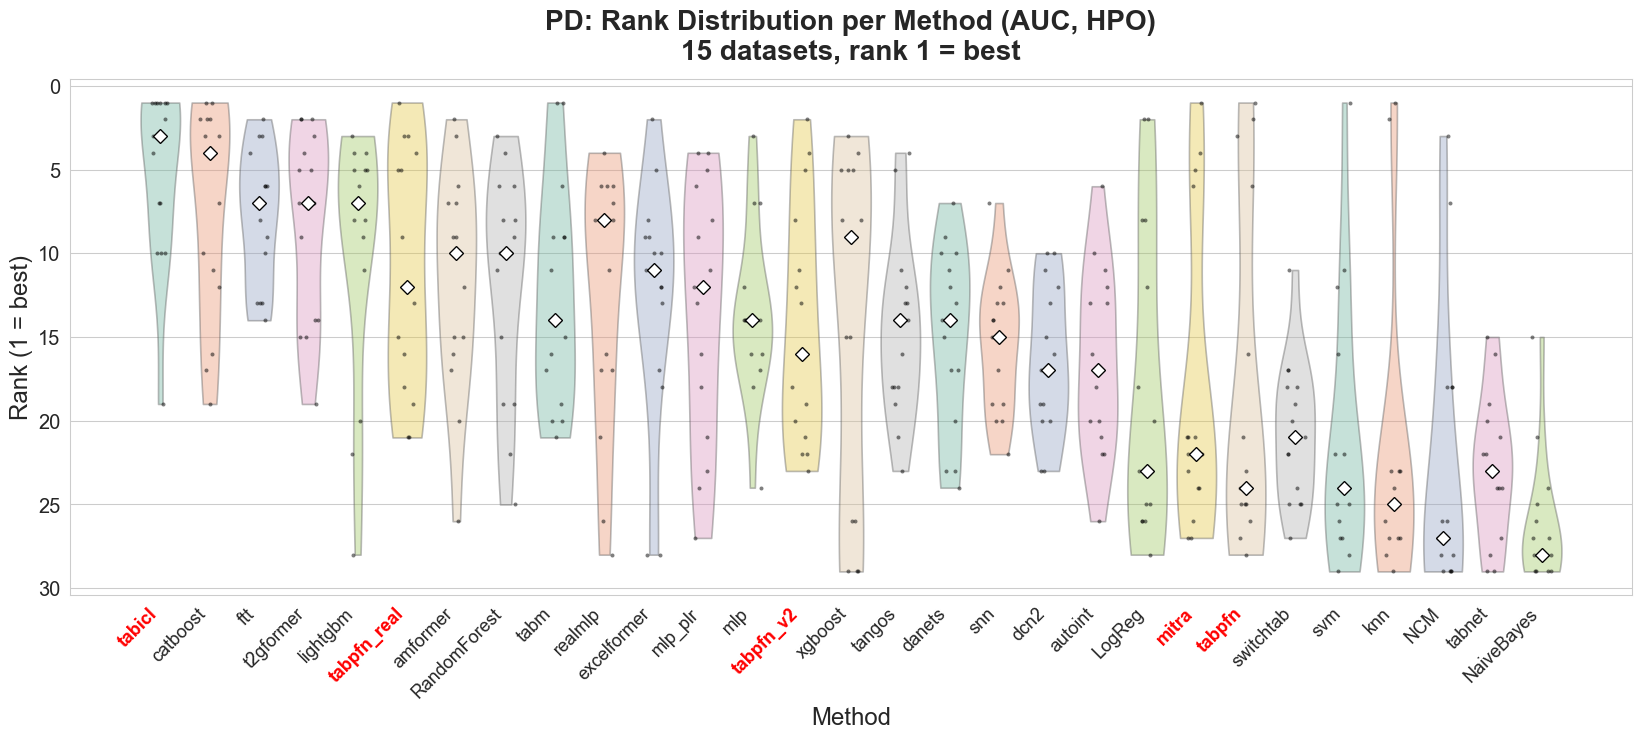

  [2/9] Bootstrap CI plot...
  Saved: pd_rank_bootstrap_ci_hpo.png


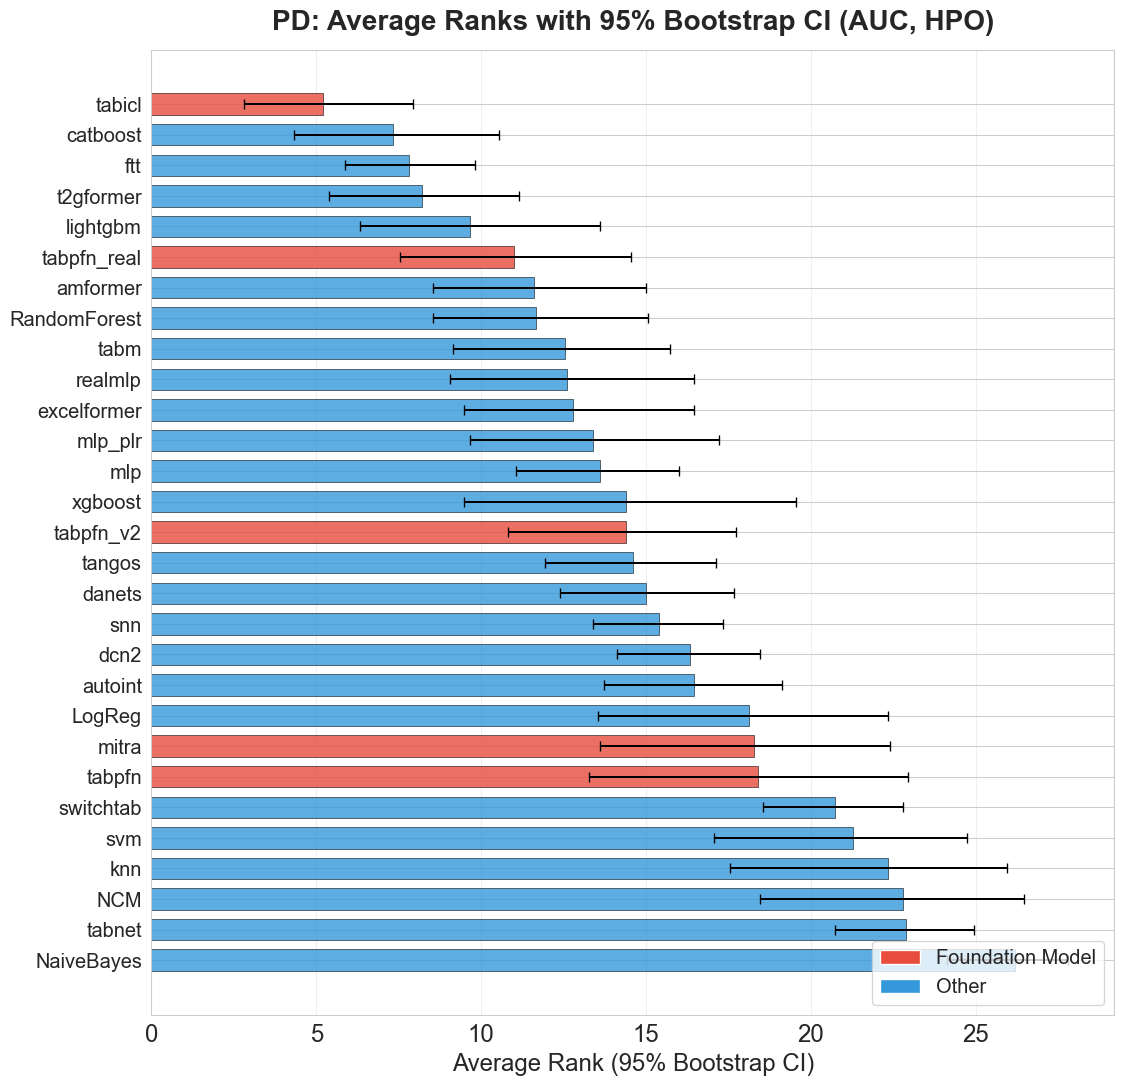

  [3/9] CD diagram (all 29 methods)...
  Saved: pd_cd_all_hpo.png


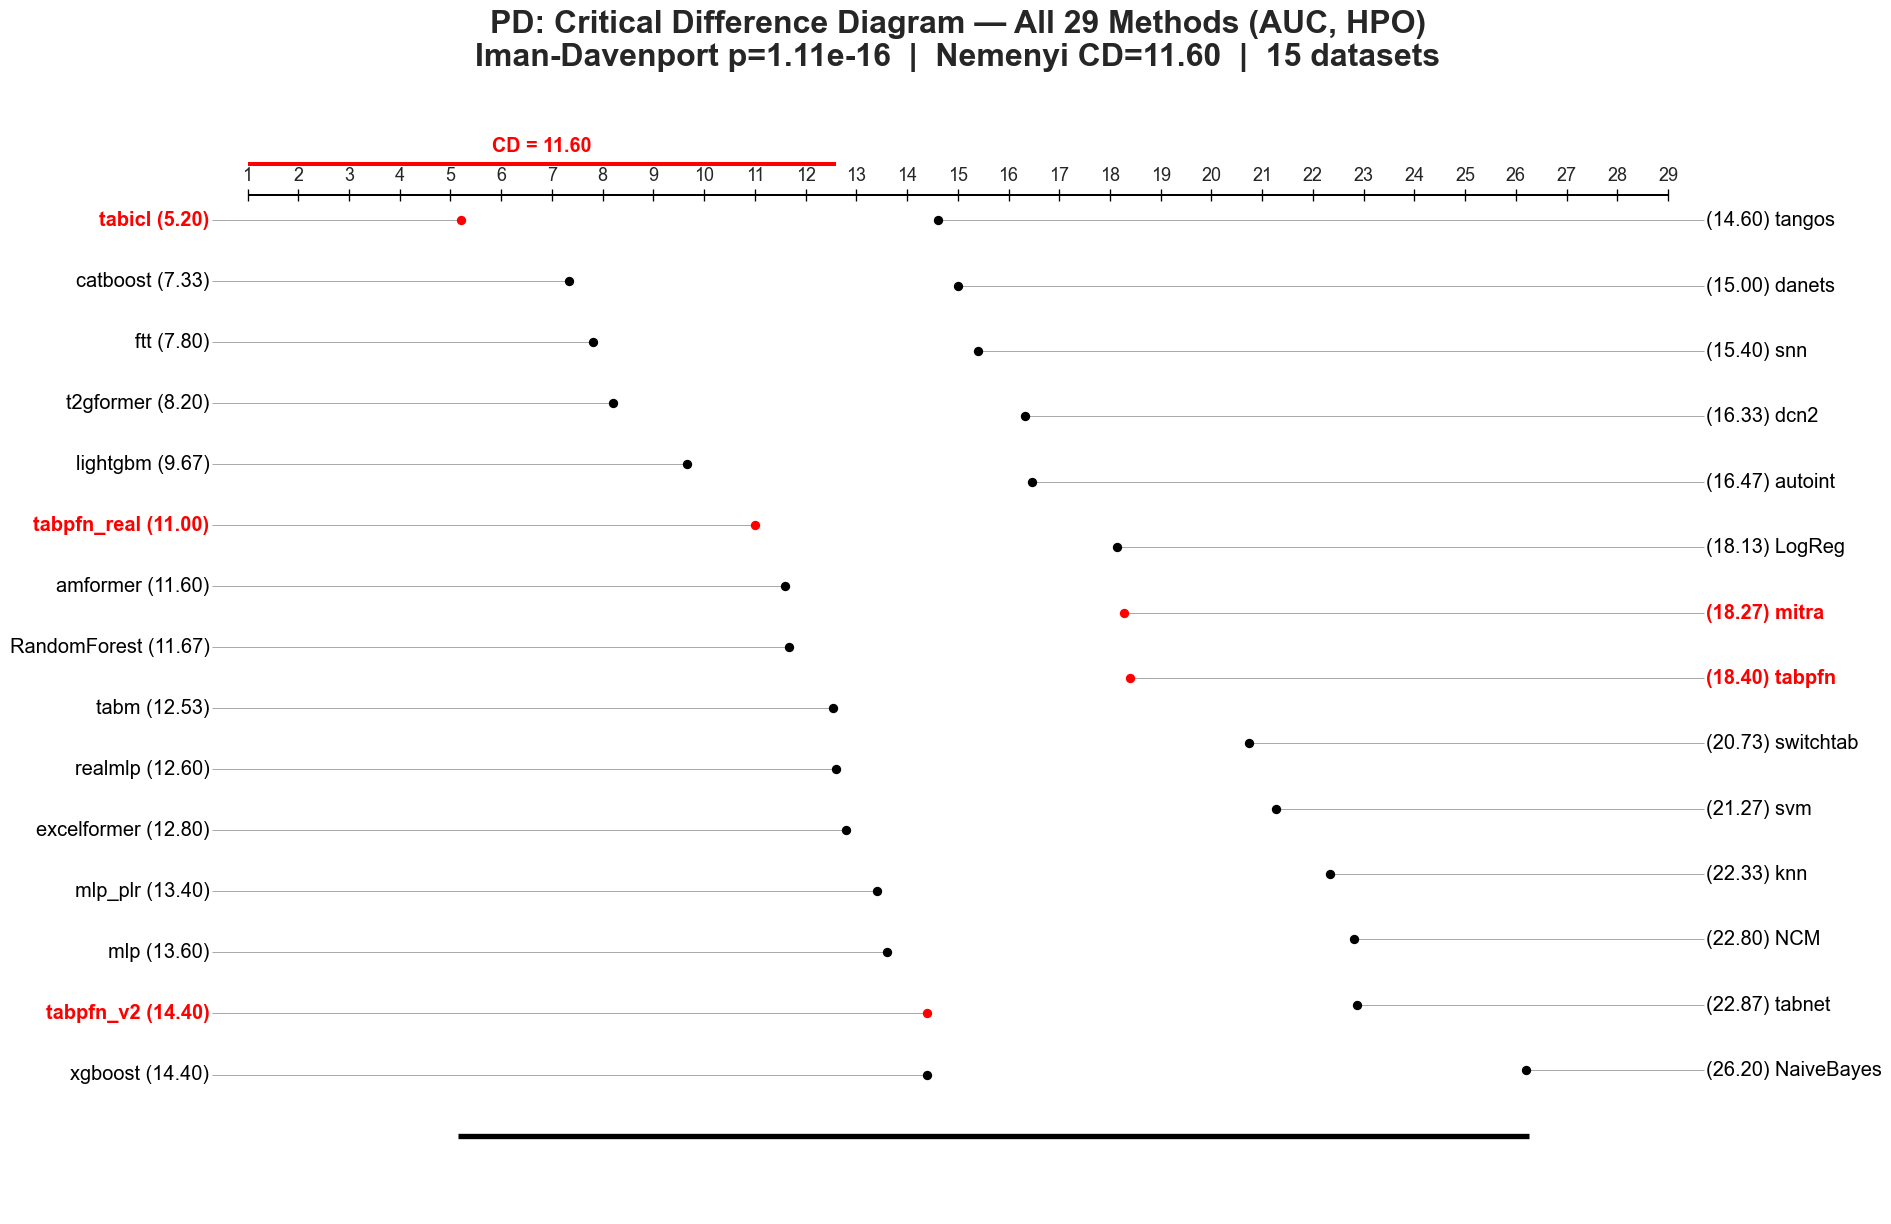

  [4/9] CD diagram (top 10)...
  Saved: pd_cd_top10_hpo.png


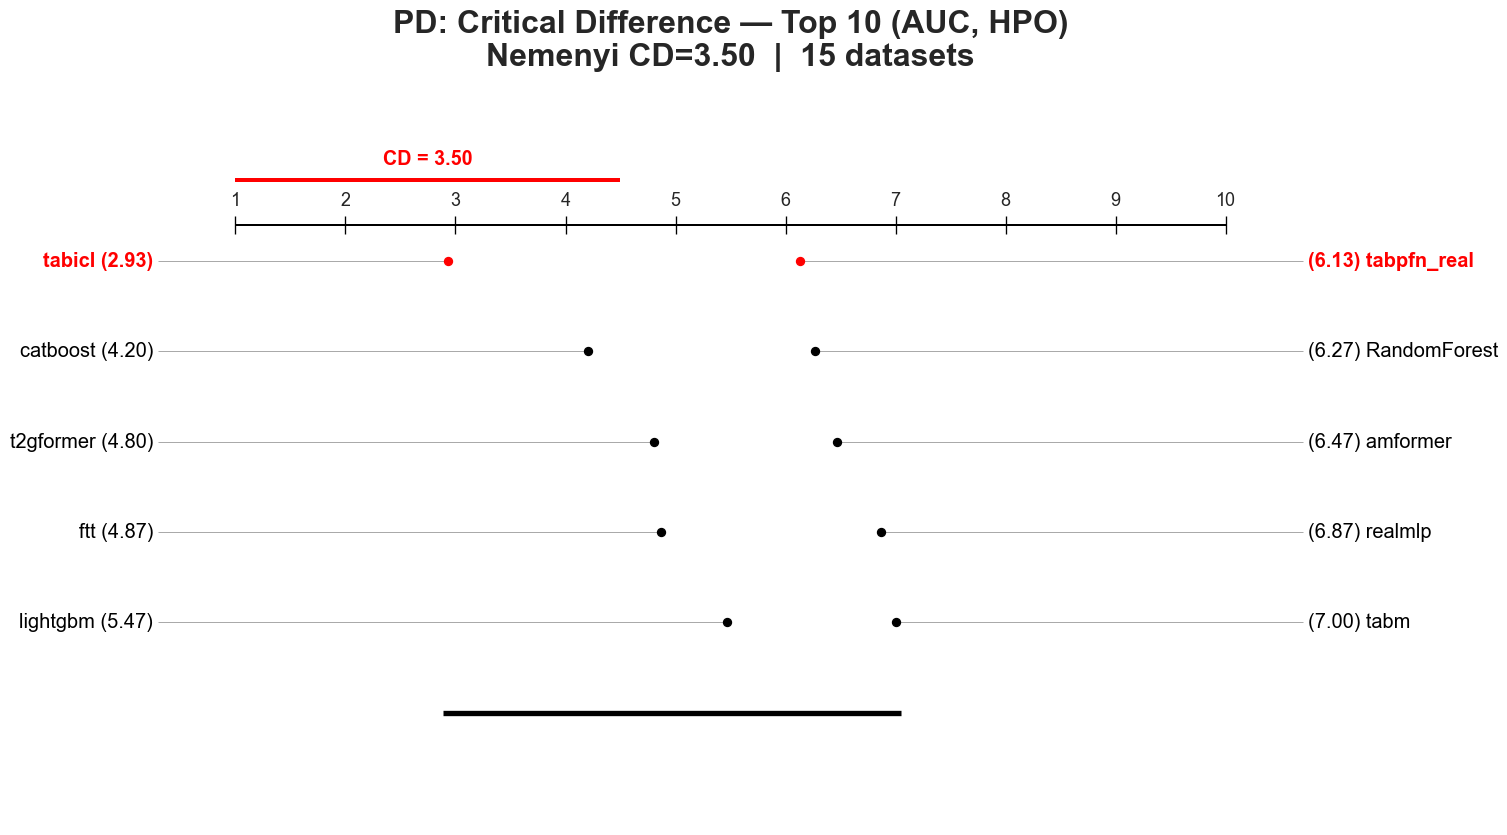

  [5/9] CD diagram (top 5)...
  Saved: pd_cd_top5_hpo.png


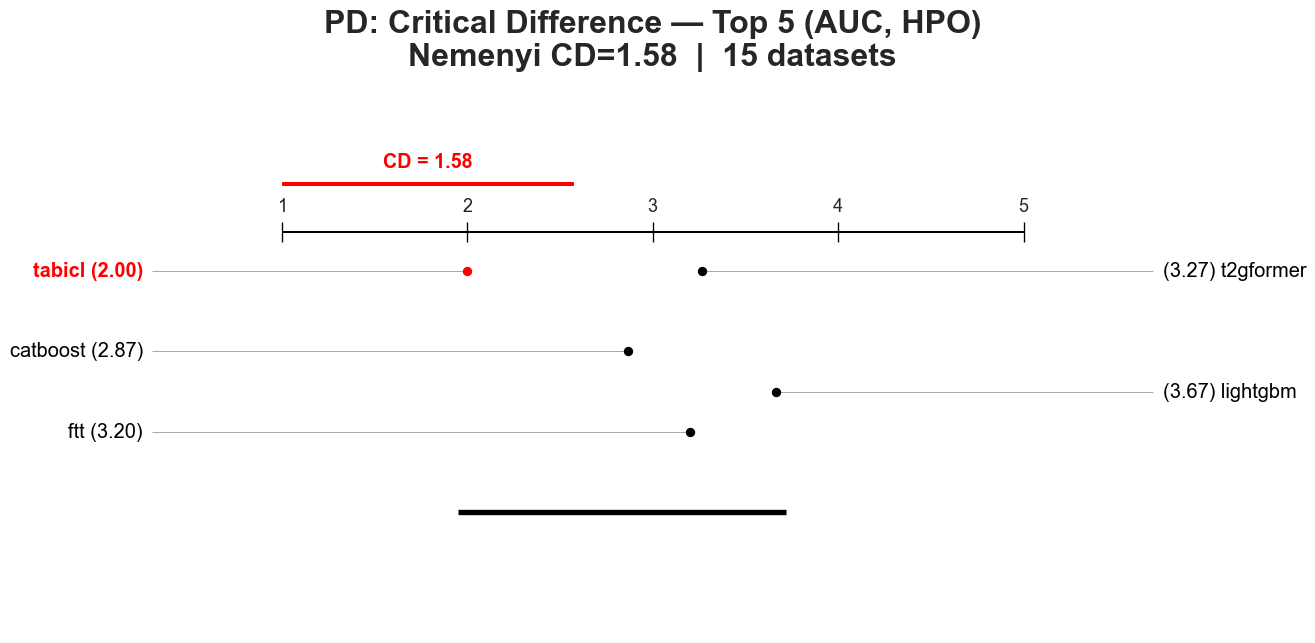

  [6/9] Significance heatmap (p-values)...
  Saved: pd_pval_heatmap_hpo.png


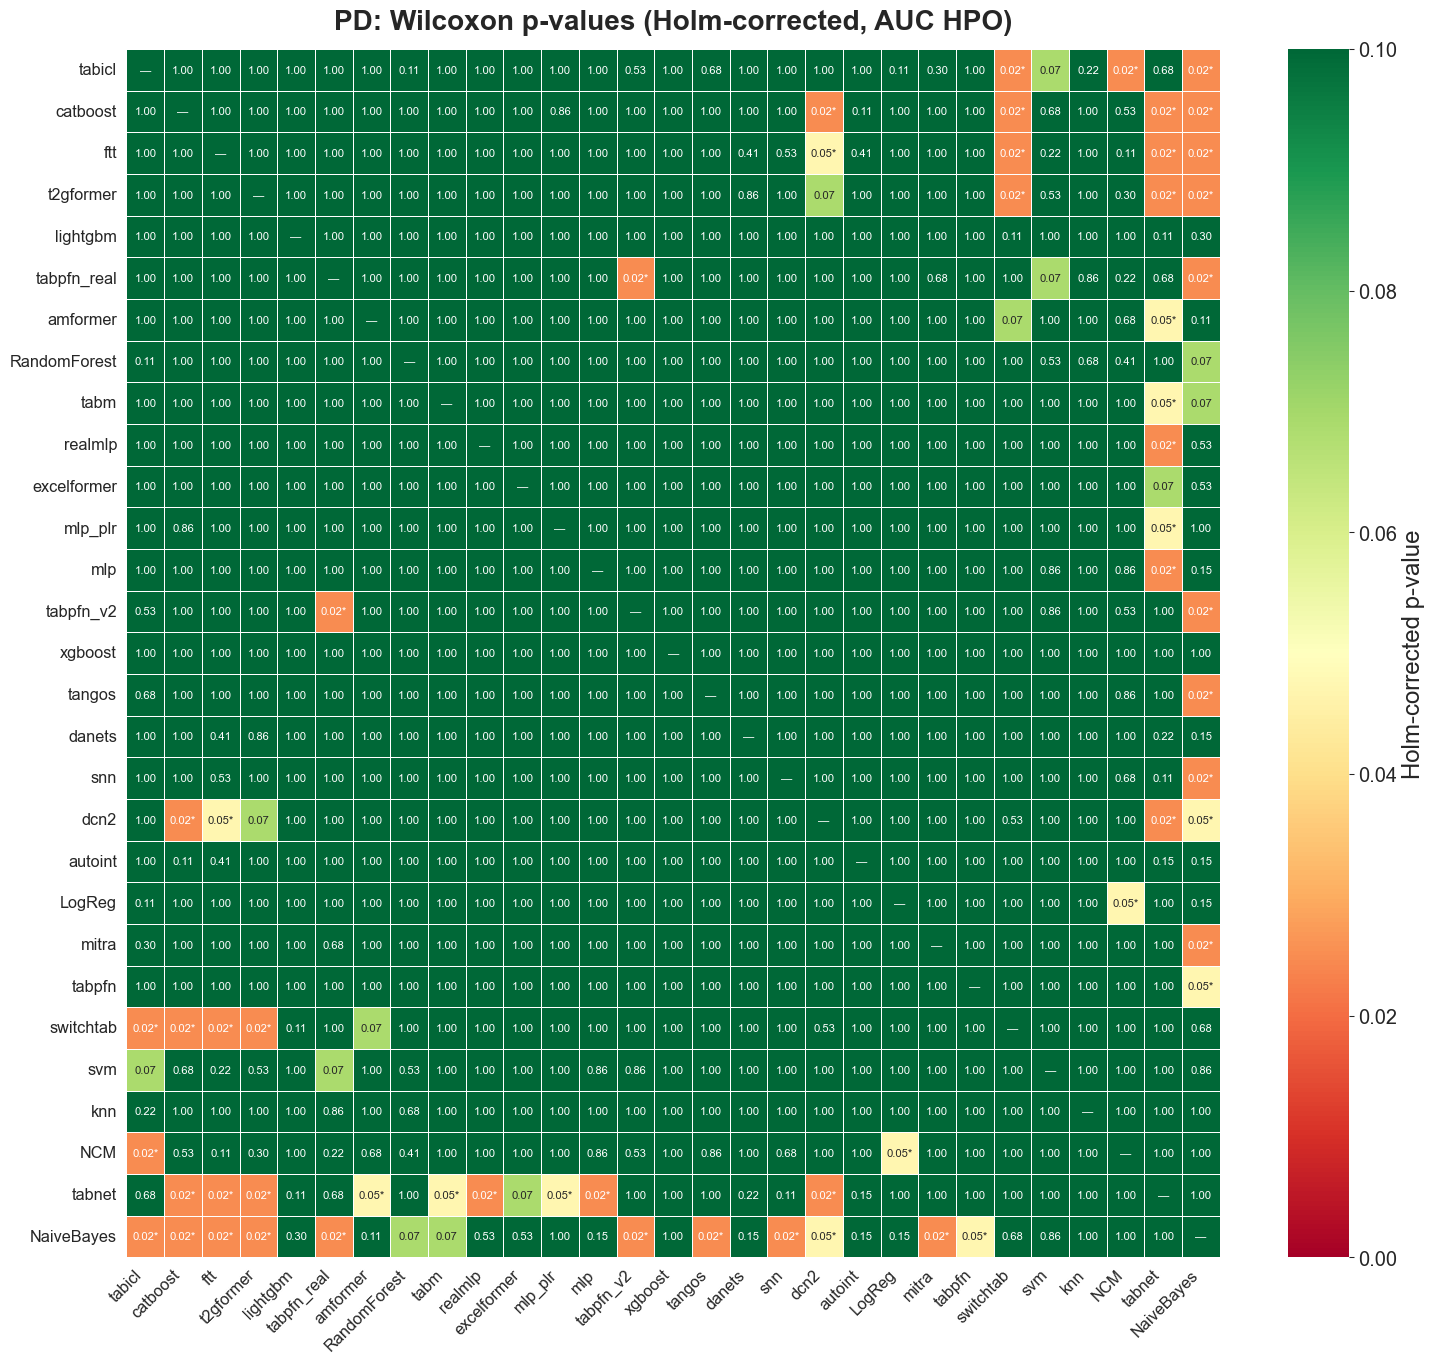

  [7/9] Effect size heatmap (Vargha-Delaney A)...
  Saved: pd_effect_heatmap_hpo.png


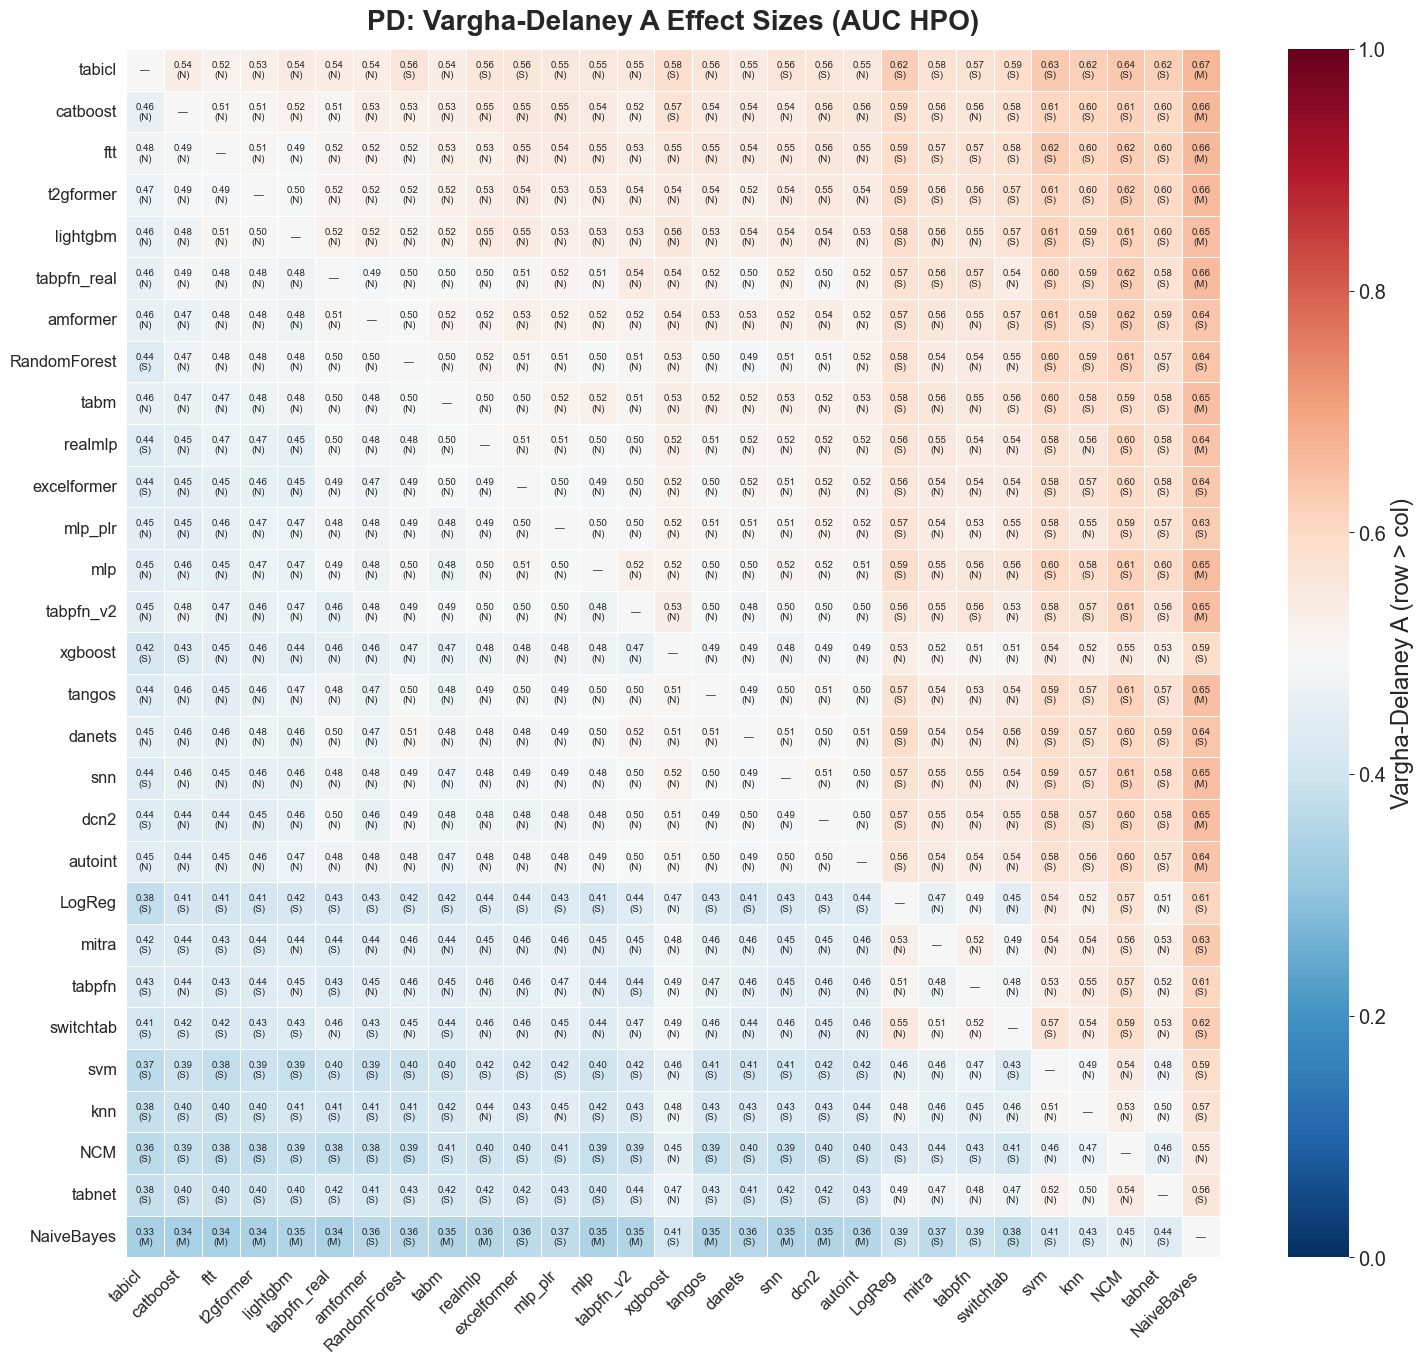

  [8/9] Win/Draw/Loss heatmap...
  Saved: pd_wdl_heatmap_hpo.png


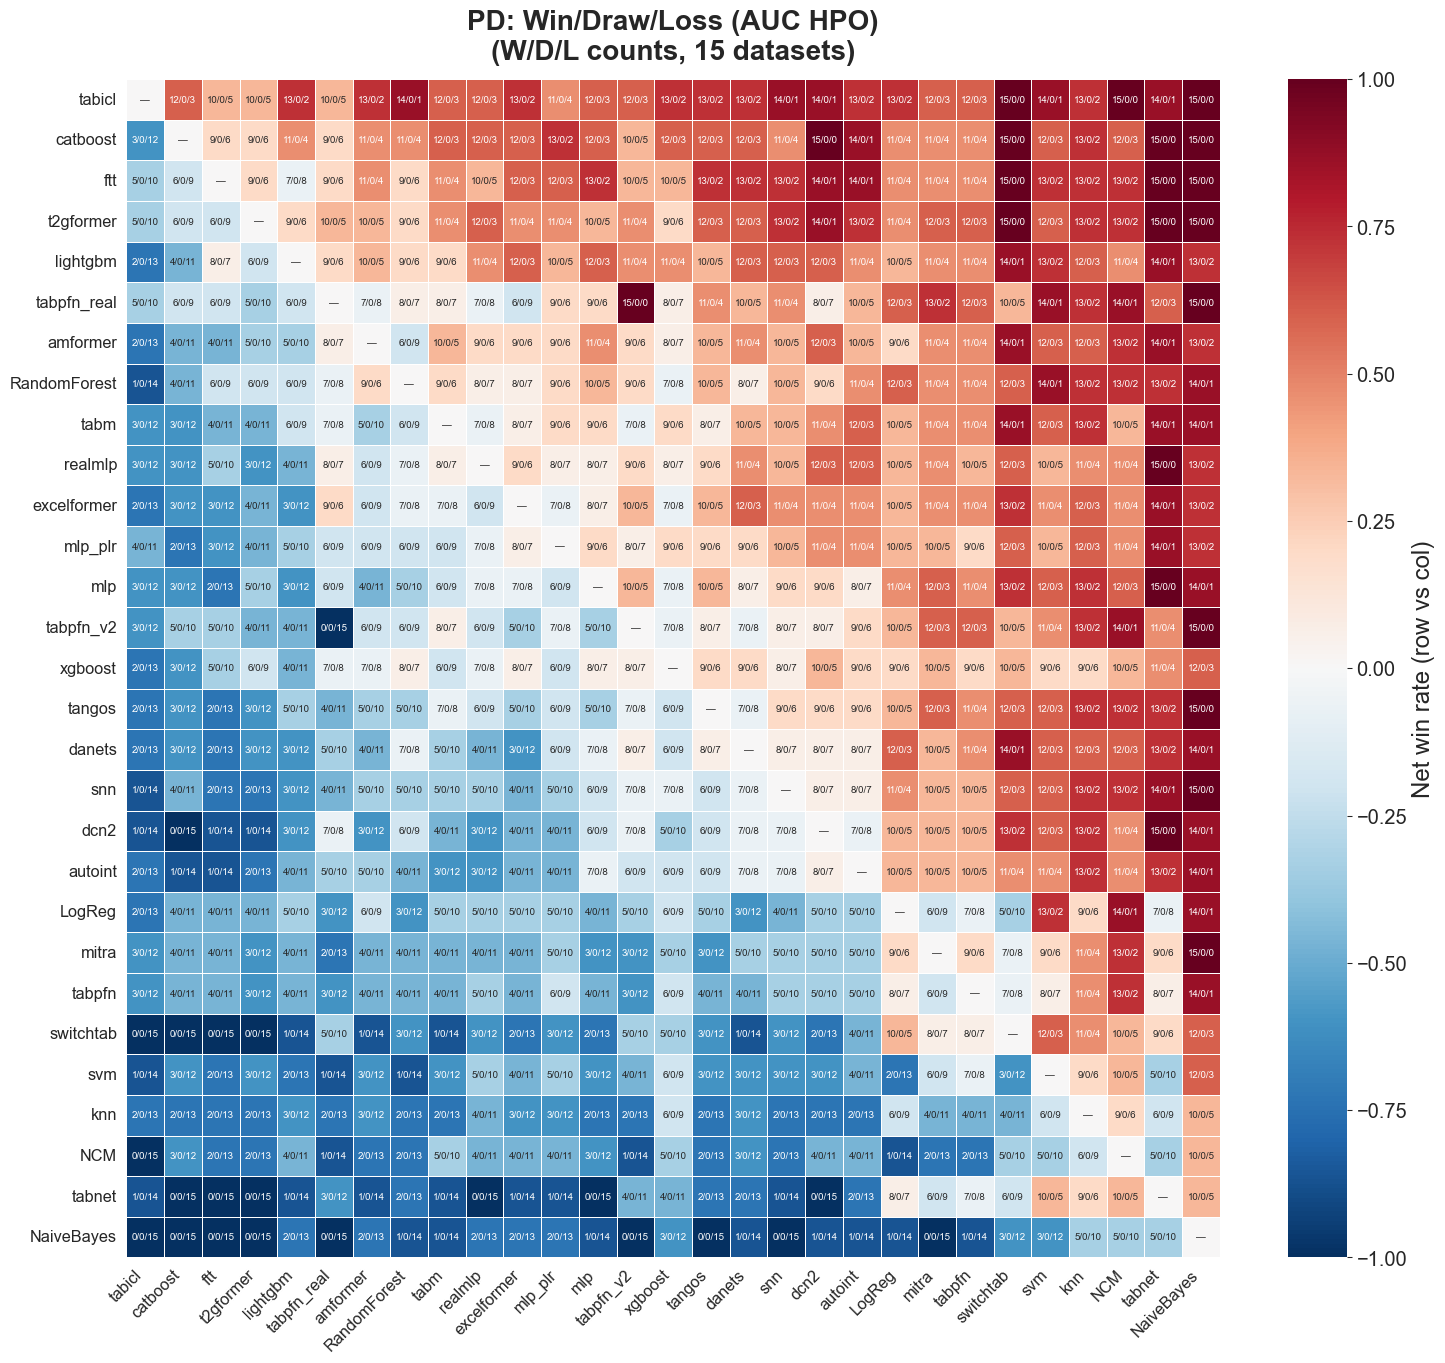

  [9/9] PAMA bar chart...
  Saved: pd_pama_hpo.png


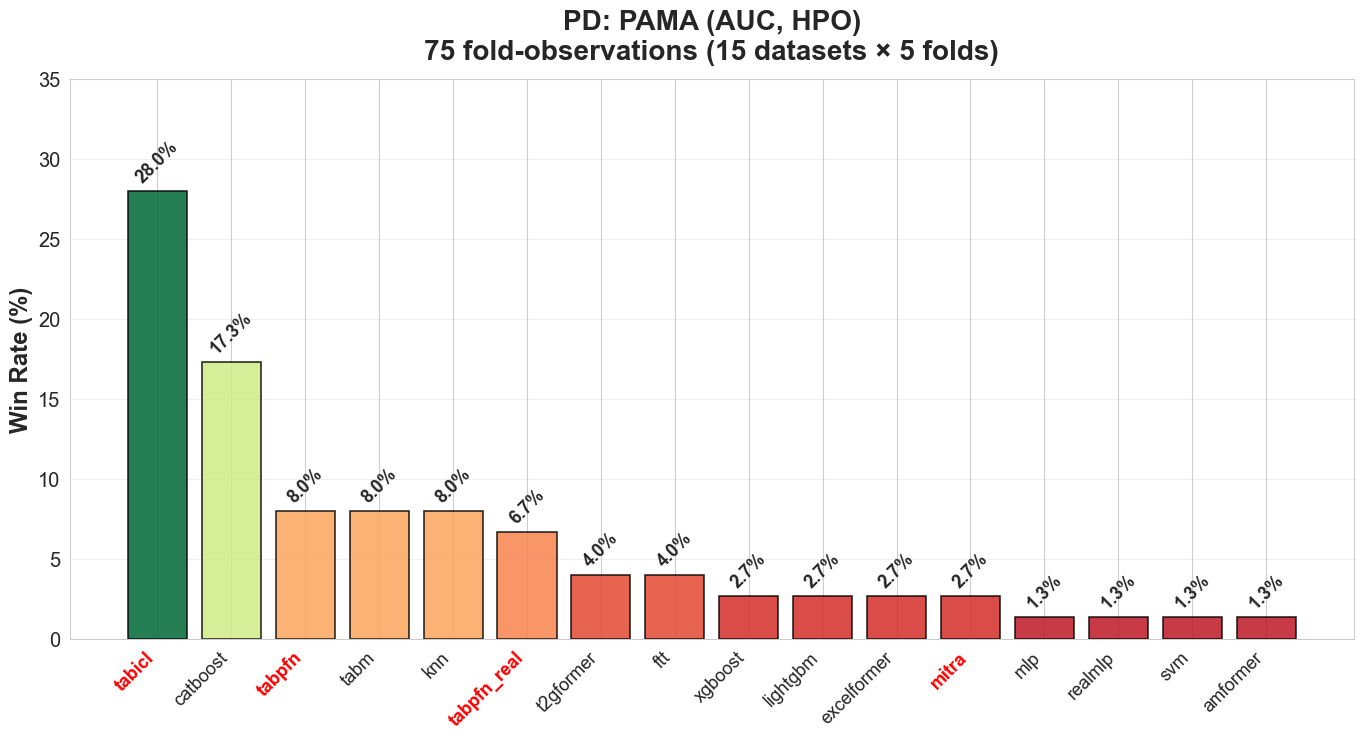


  Pairwise scatter plots (top methods)...
  Saved: pd_scatter_tabicl_vs_catboost_hpo.png


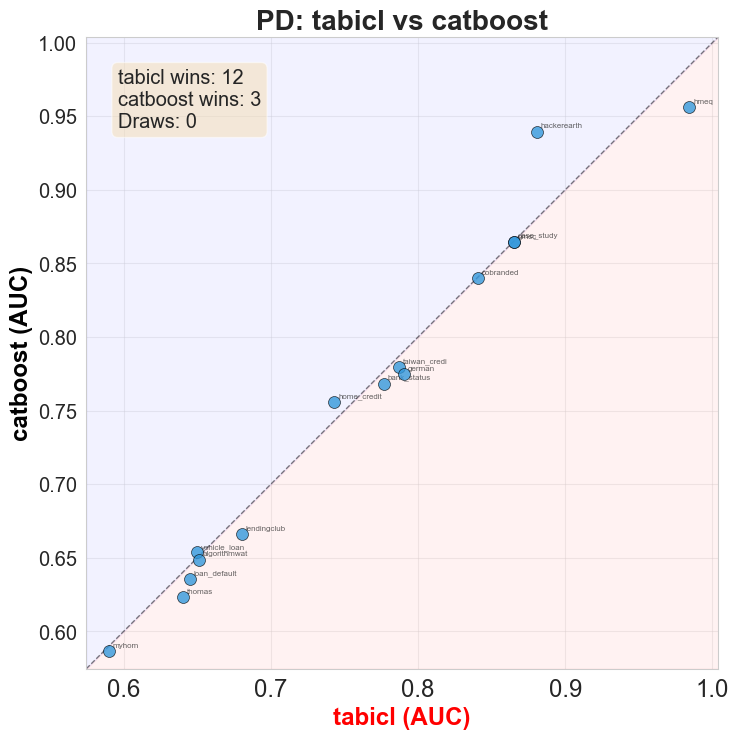

  Saved: pd_scatter_tabicl_vs_ftt_hpo.png


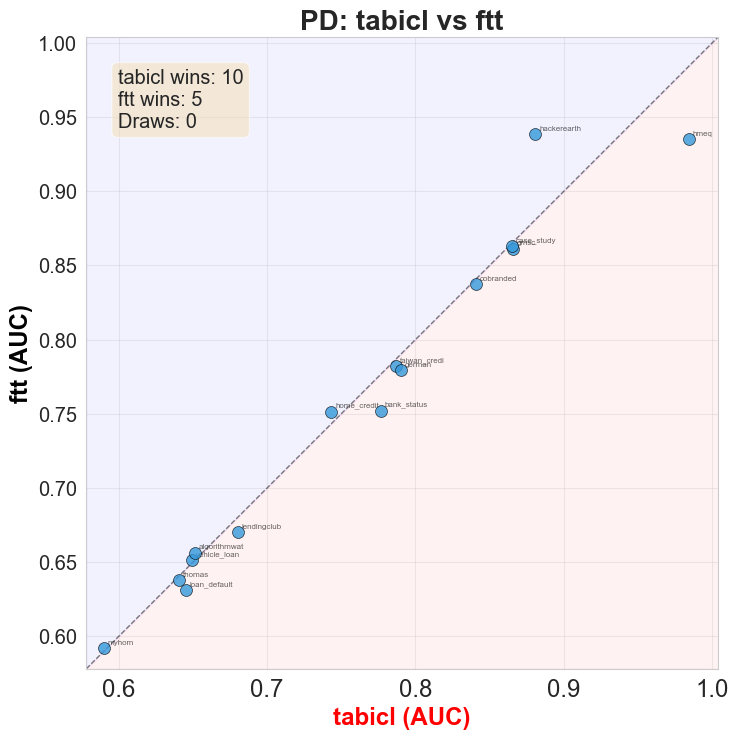

  Saved: pd_scatter_catboost_vs_ftt_hpo.png


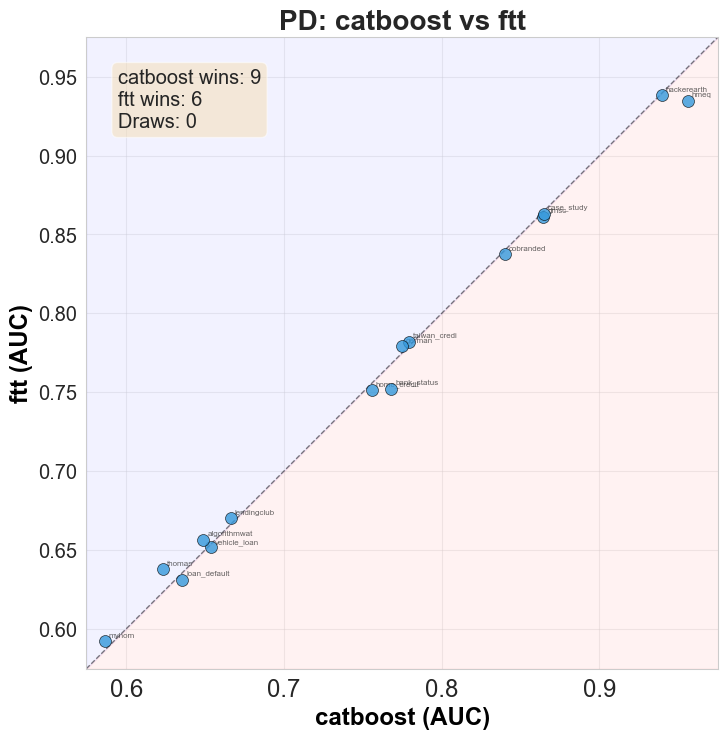


  PD — STATISTICAL SUMMARY
  Metric: AUC (HPO)
  N = 15 datasets, k = 29 methods

  Friedman-Iman-Davenport: p = 1.11e-16  (SIGNIFICANT)
  Nemenyi CD (α=0.05) = 11.603
  Wilcoxon+Holm: 29/406 significant pairs
  PAMA winner: tabicl (28.0% wins)

  Top-5 by average rank:
    1. tabicl                     rank=5.20  [2.80, 7.93] (FM)
    2. catboost                   rank=7.33  [4.33, 10.53]
    3. ftt                        rank=7.80  [5.87, 9.80]
    4. t2gformer                  rank=8.20  [5.40, 11.13]
    5. lightgbm                   rank=9.67  [6.33, 13.60]

  Effect sizes: 0 large, 14 medium, 135 small, 257 negligible


In [6]:
run_full_statistical_analysis(
    pd_raw, 'AUC', 'PD',
    higher_is_better=True,
    foundation_methods=FOUNDATION_METHODS,
    save_dir=FIGURES_DIR
)

---
# Section 2: LGD (Loss Given Default) — R²

Statistical analysis of LGD model performance using R² as the evaluation metric.

**Observation unit:** 1 dataset = mean R² across 5 CV folds.
**PAMA unit:** 1 fold = individual (dataset, fold) observation.

## 2.1 Full Statistical Analysis (LGD, R², HPO)


  LGD — COMPREHENSIVE STATISTICAL ANALYSIS (R2, HPO)

──────────────────────────────────────────────────────────────────────
  A. DESCRIPTIVE STATISTICS
──────────────────────────────────────────────────────────────────────
  Datasets (N) = 7,  Methods (k) = 22
  Metric: R2 (higher is better)
  Unit of analysis: 1 dataset = mean(R2) across 5 CV folds

  Method                        Mean      Std   Median      IQR      Min      Max
  ------------------------- -------- -------- -------- -------- -------- --------
  catboost                    0.4401   0.2170   0.4276   0.3007   0.1655   0.7450
  tabpfn_v2                   0.4455   0.2385   0.3749   0.4107   0.1816   0.7460 *
  realmlp                     0.4203   0.2254   0.3795   0.3064   0.1155   0.7298
  lightgbm                    0.4334   0.2338   0.3970   0.3379   0.1136   0.7421
  excelformer                 0.4132   0.2383   0.3553   0.3340   0.0902   0.7341
  tabm                        0.4206   0.2273   0.3726   0.3363   0.1

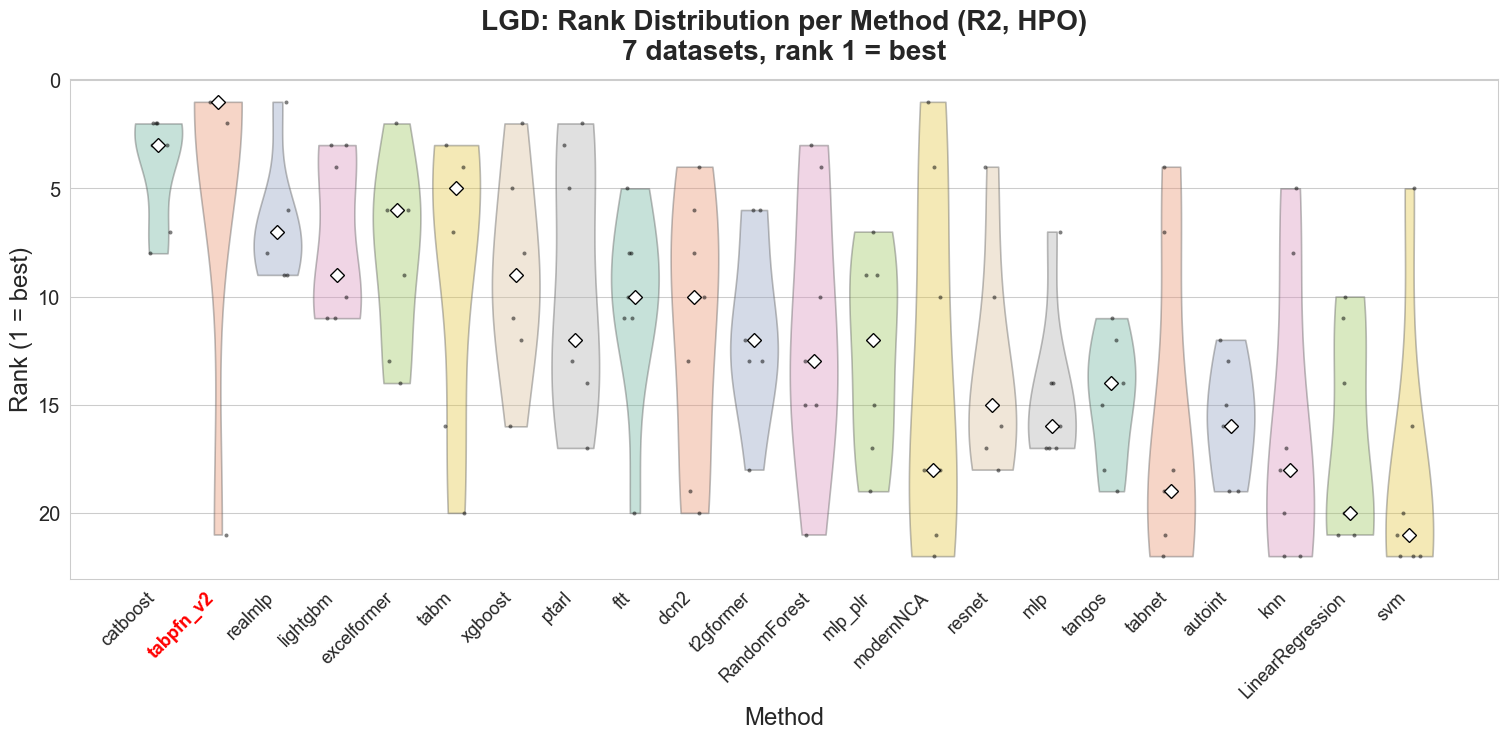

  [2/9] Bootstrap CI plot...
  Saved: lgd_rank_bootstrap_ci_hpo.png


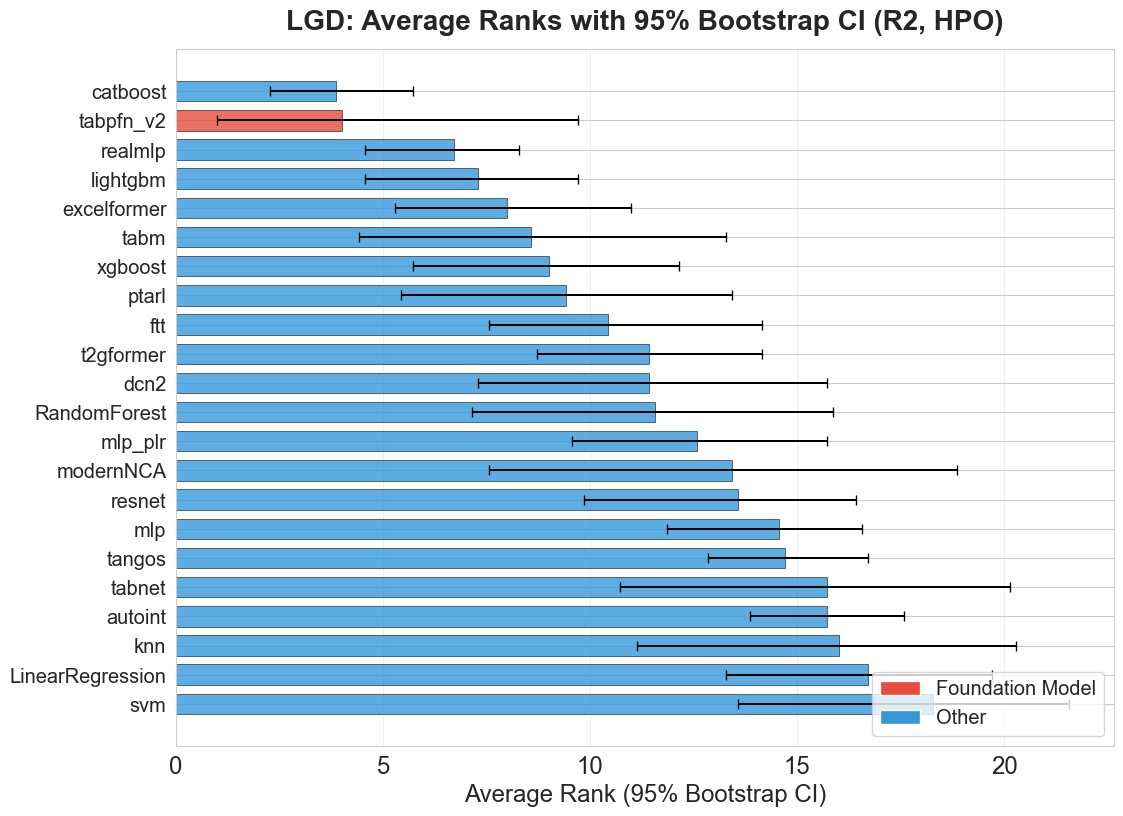

  [3/9] CD diagram (all 22 methods)...
  Saved: lgd_cd_all_hpo.png


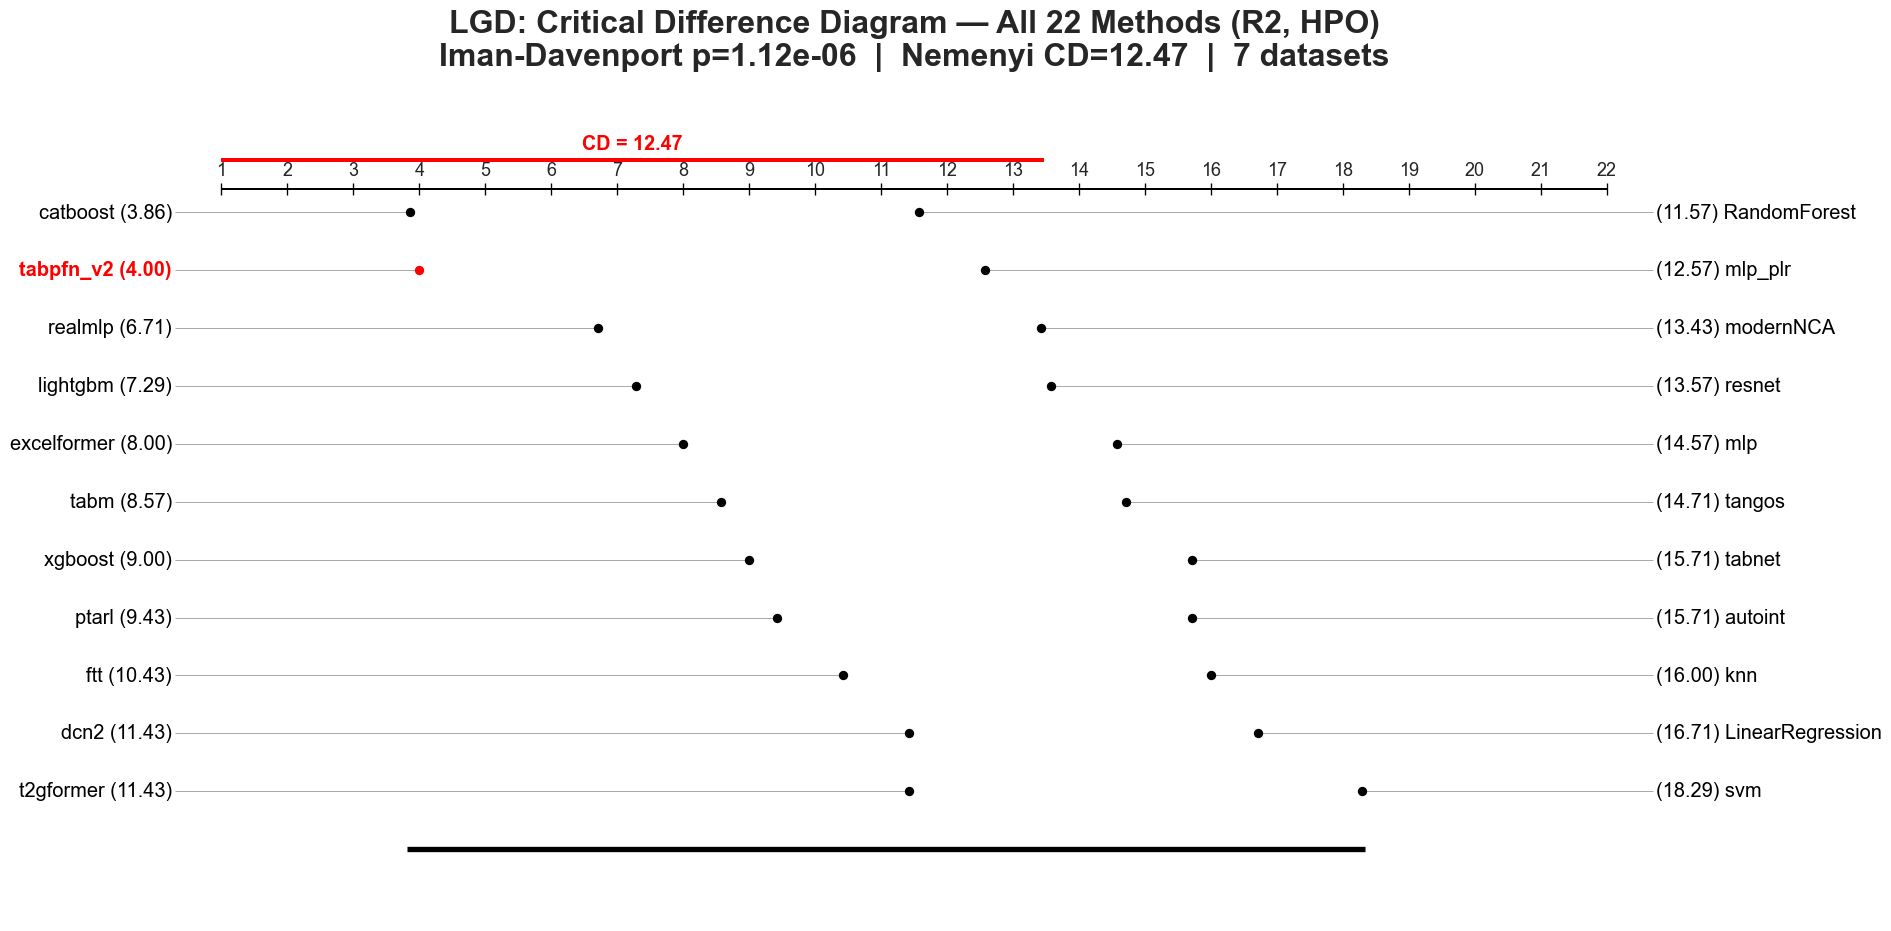

  [4/9] CD diagram (top 10)...
  Saved: lgd_cd_top10_hpo.png


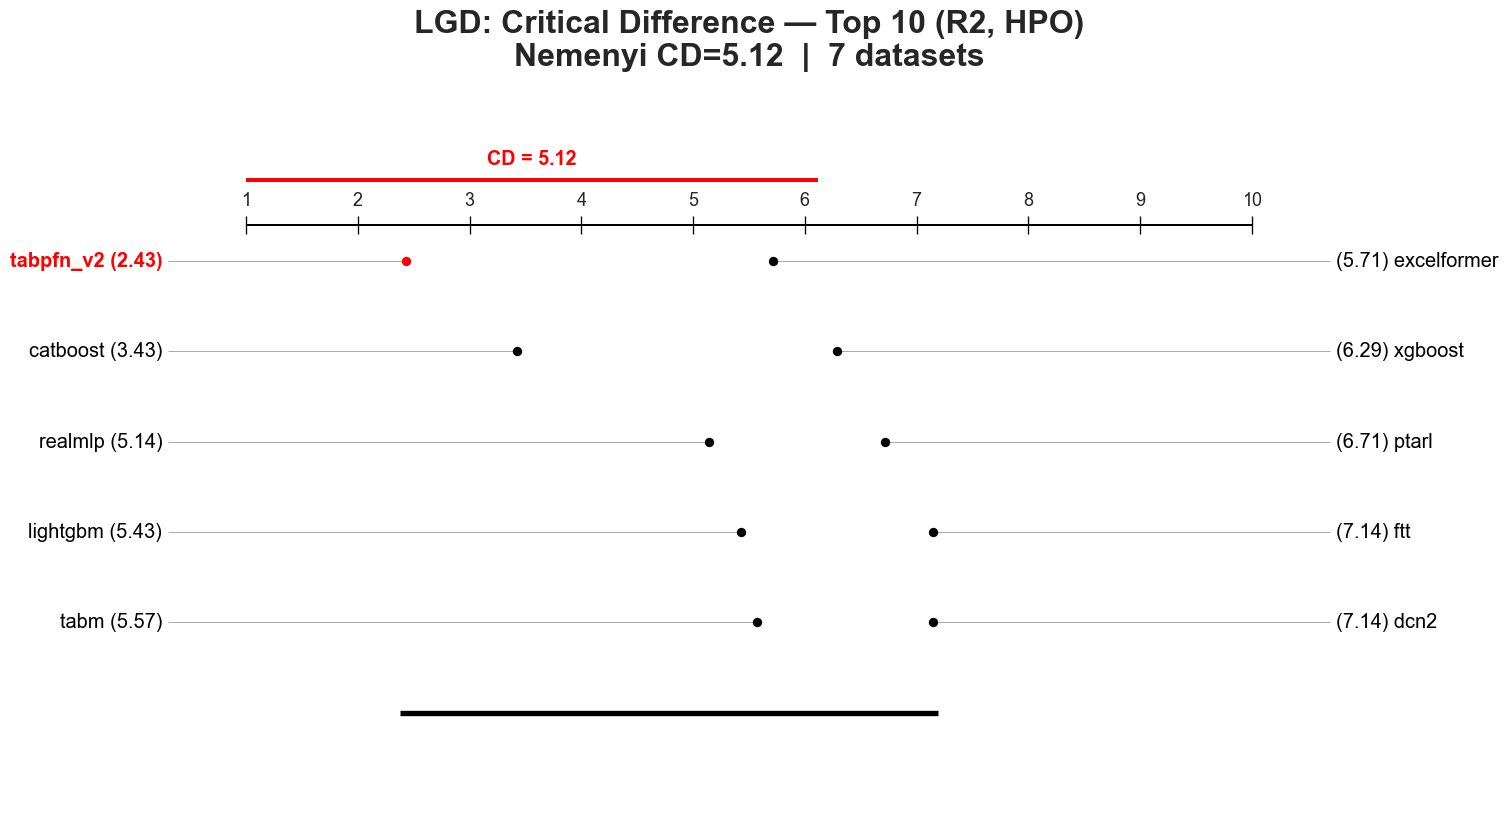

  [5/9] CD diagram (top 5)...
  Saved: lgd_cd_top5_hpo.png


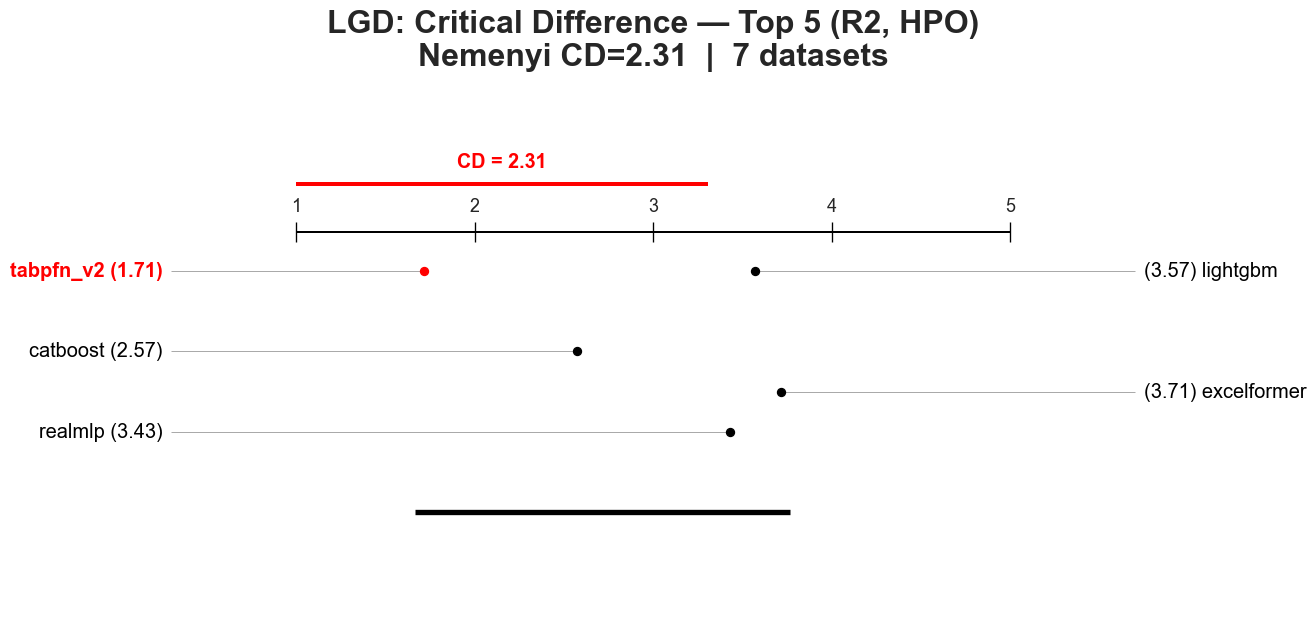

  [6/9] Significance heatmap (p-values)...
  Saved: lgd_pval_heatmap_hpo.png


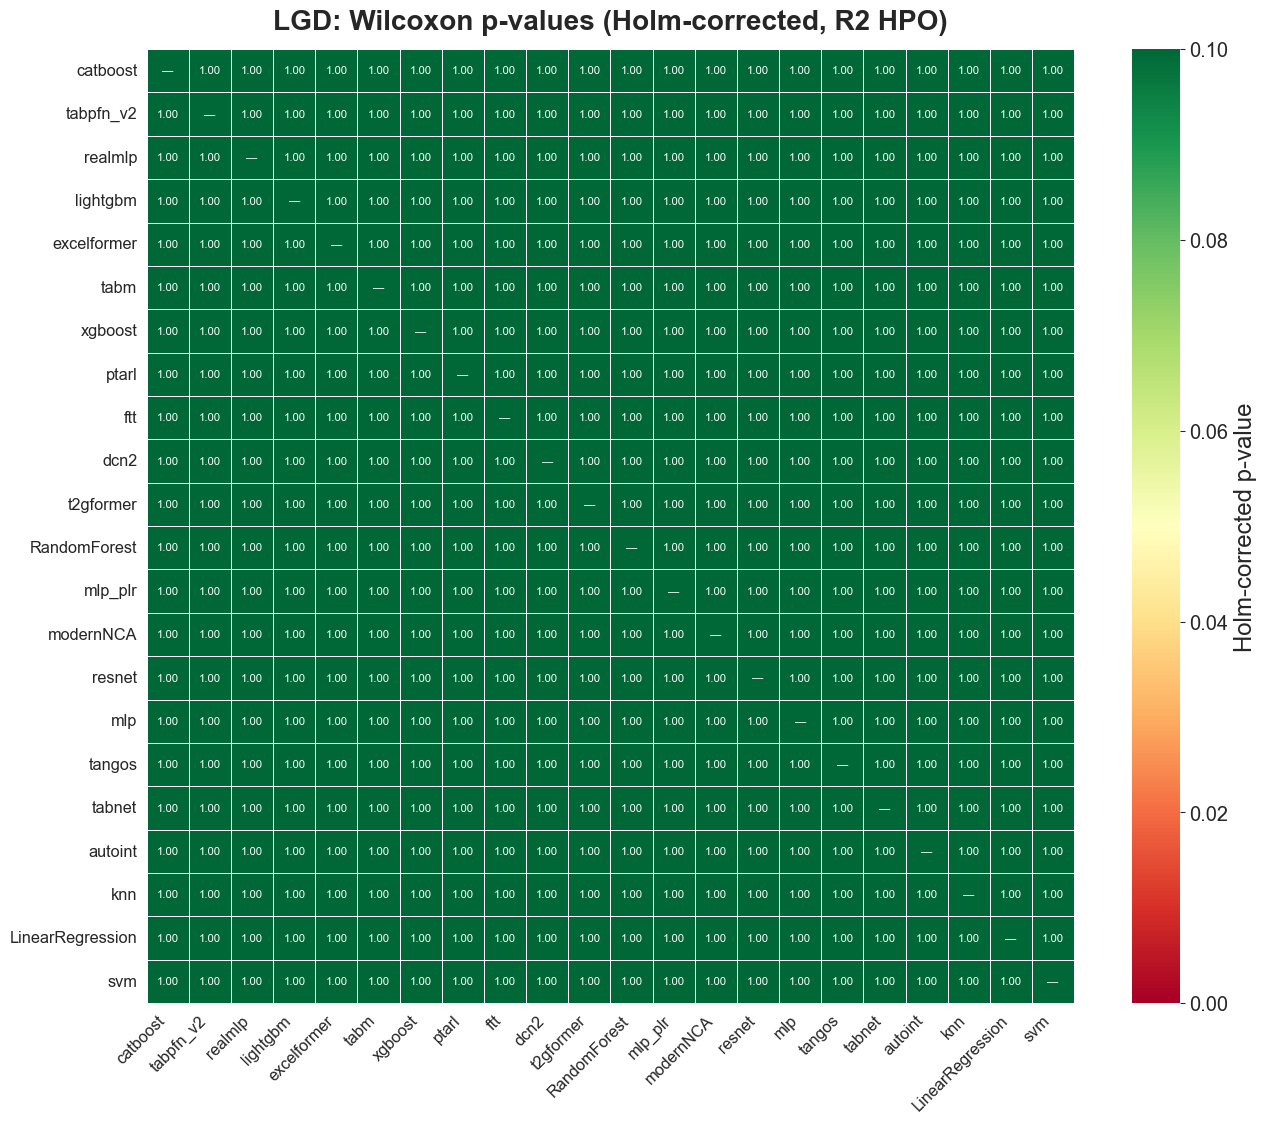

  [7/9] Effect size heatmap (Vargha-Delaney A)...
  Saved: lgd_effect_heatmap_hpo.png


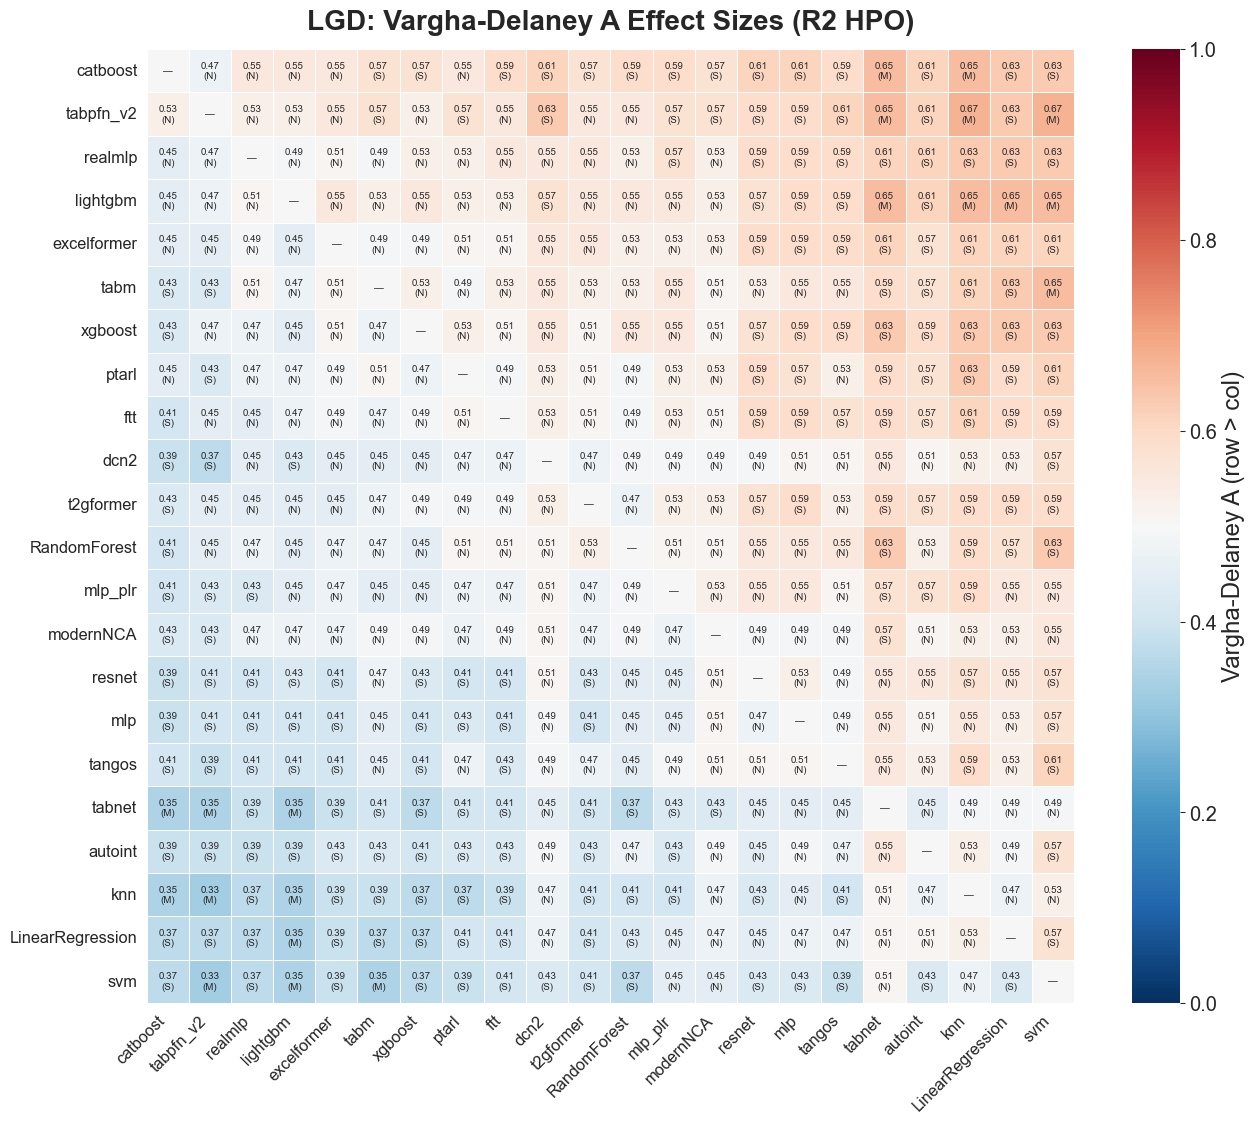

  [8/9] Win/Draw/Loss heatmap...
  Saved: lgd_wdl_heatmap_hpo.png


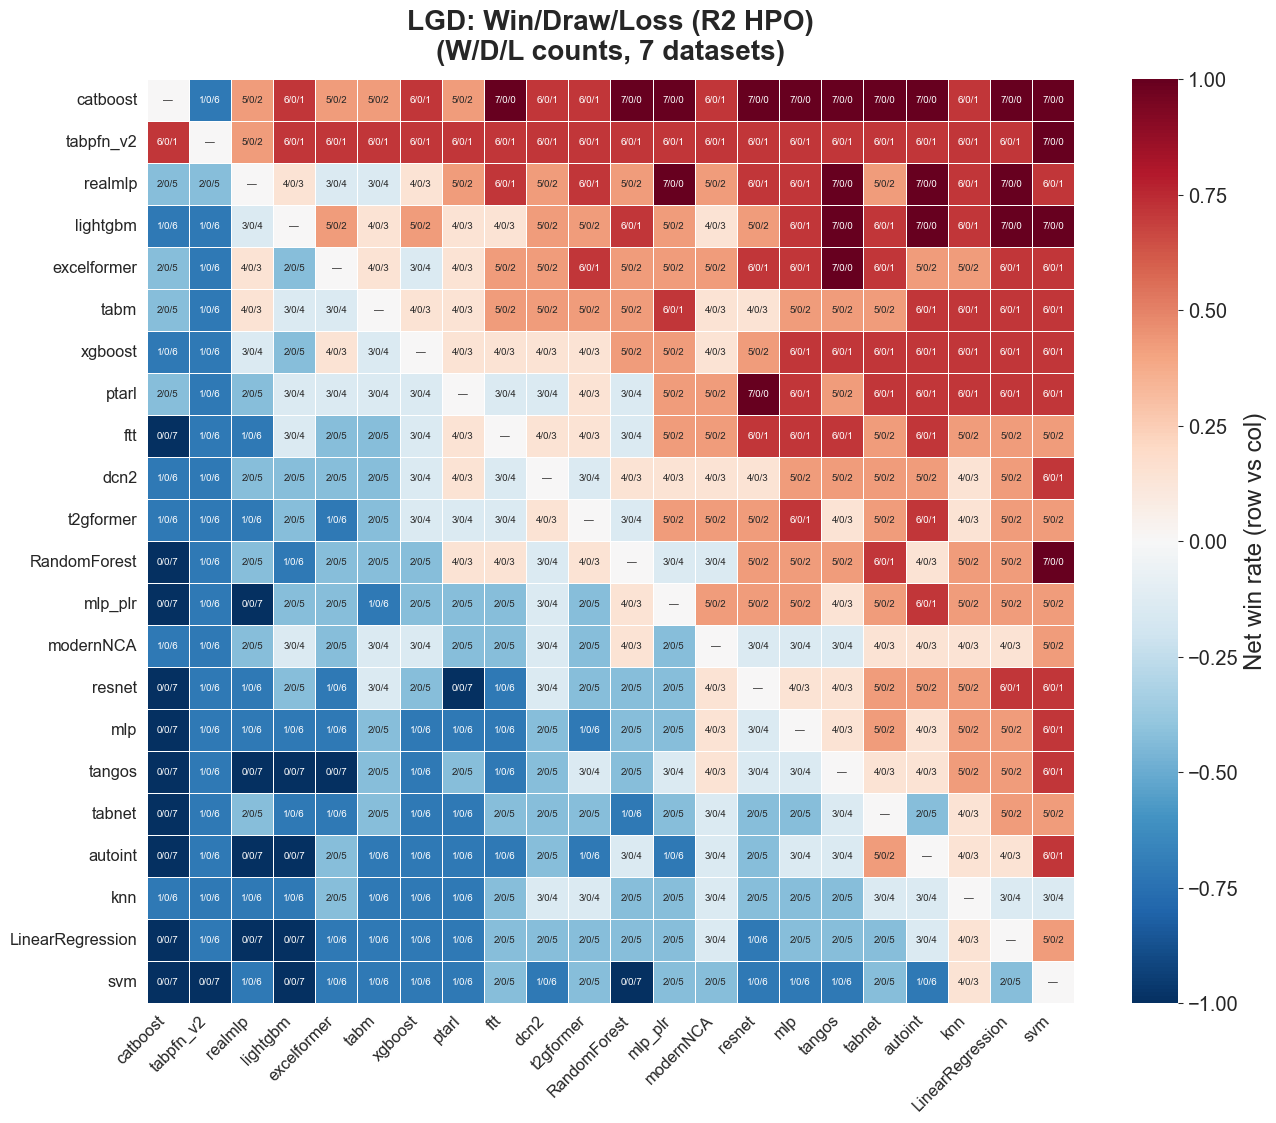

  [9/9] PAMA bar chart...
  Saved: lgd_pama_hpo.png


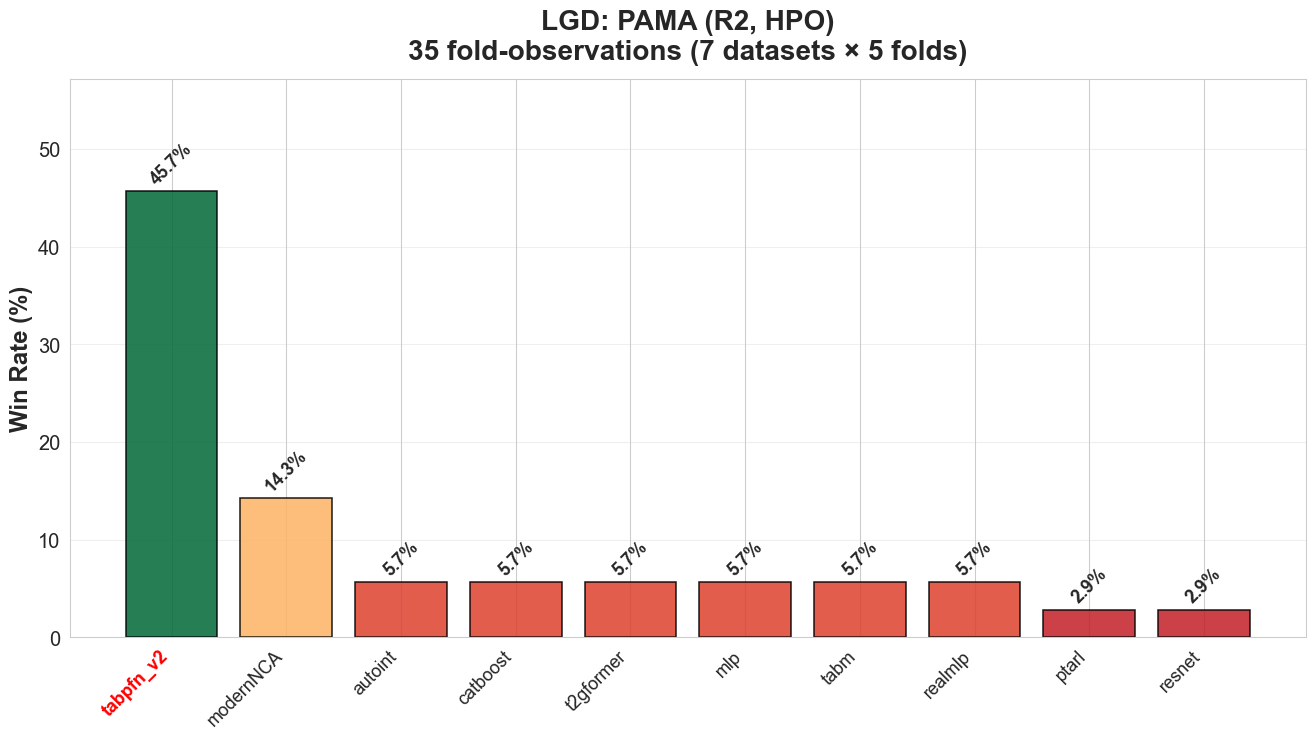


  Pairwise scatter plots (top methods)...
  Saved: lgd_scatter_catboost_vs_tabpfn_v2_hpo.png


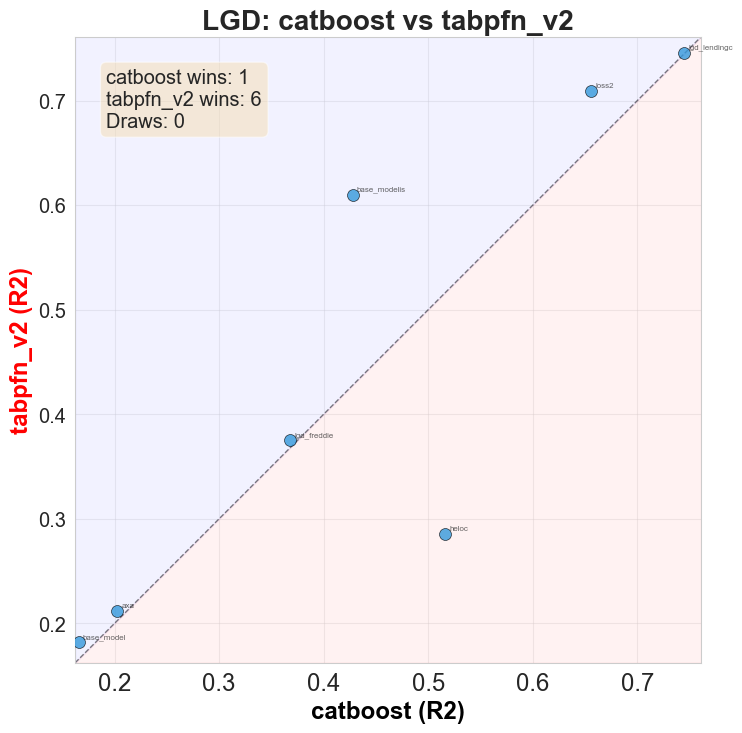

  Saved: lgd_scatter_catboost_vs_realmlp_hpo.png


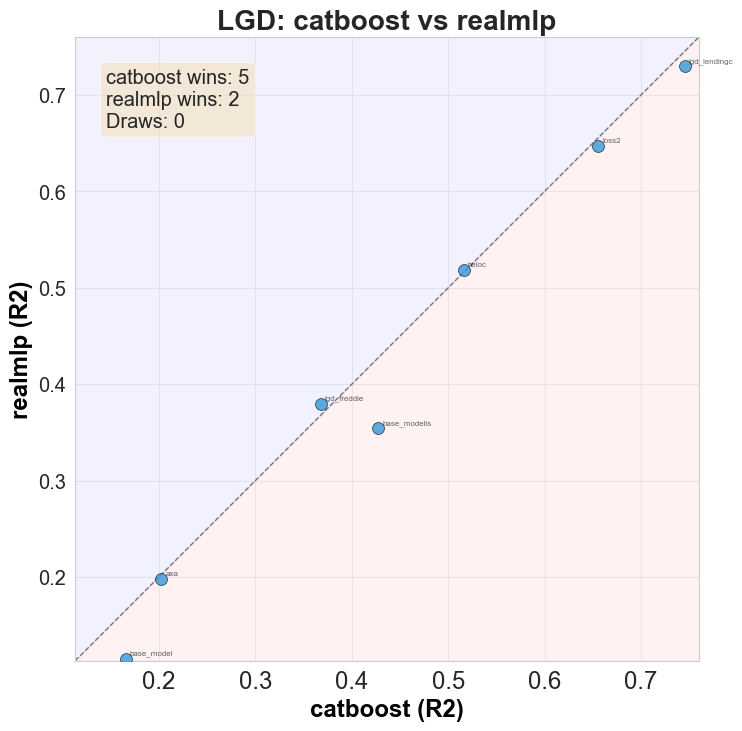

  Saved: lgd_scatter_tabpfn_v2_vs_realmlp_hpo.png


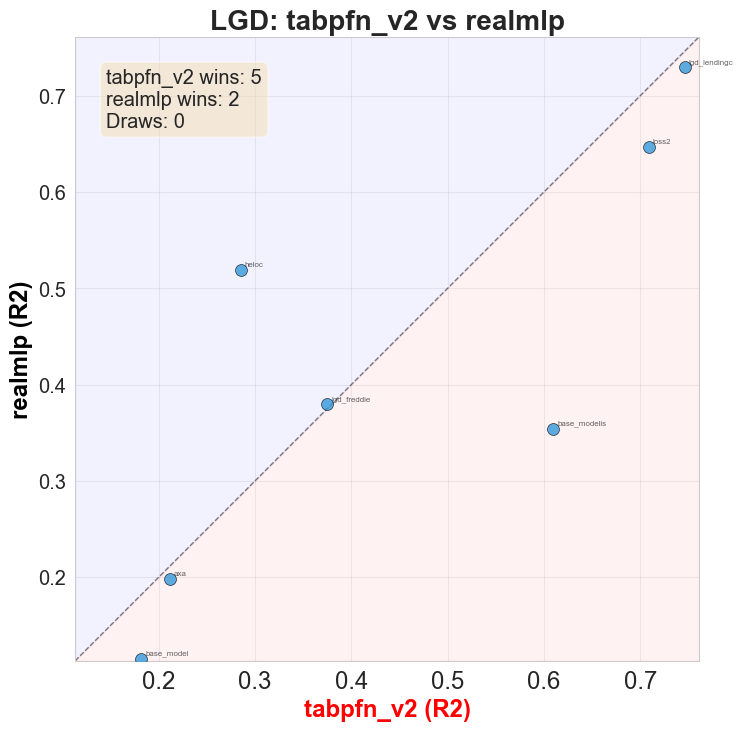


  LGD — STATISTICAL SUMMARY
  Metric: R2 (HPO)
  N = 7 datasets, k = 22 methods

  Friedman-Iman-Davenport: p = 1.12e-06  (SIGNIFICANT)
  Nemenyi CD (α=0.05) = 12.471
  Wilcoxon+Holm: 0/231 significant pairs
  PAMA winner: tabpfn_v2 (45.7% wins)

  Top-5 by average rank:
    1. catboost                   rank=3.86  [2.29, 5.71]
    2. tabpfn_v2                  rank=4.00  [1.00, 9.71] (FM)
    3. realmlp                    rank=6.71  [4.57, 8.29]
    4. lightgbm                   rank=7.29  [4.57, 9.71]
    5. excelformer                rank=8.00  [5.29, 11.00]

  Effect sizes: 0 large, 10 medium, 96 small, 125 negligible


In [7]:
run_full_statistical_analysis(
    lgd_raw, 'R2', 'LGD',
    higher_is_better=True,
    foundation_methods=FOUNDATION_METHODS,
    save_dir=FIGURES_DIR
)

---
## Summary & Methodological Notes

### Statistical Tests Performed

| Test | Purpose | Reference |
|------|---------|-----------|
| Friedman (+ Iman-Davenport) | Omnibus: any differences among k methods? | Demsar (2006) §3.2 |
| Nemenyi | All-vs-all post-hoc (rank-based, CD diagram) | Demsar (2006) §3.2.2 |
| Wilcoxon signed-rank + Holm | All-vs-all post-hoc (more powerful, value-based) | Garcia & Herrera (2008) |
| Vargha-Delaney A | Non-parametric effect size (probability of superiority) | Vargha & Delaney (2000) |
| Cliff's delta | Standardized non-parametric effect size (δ = 2A − 1) | Cliff (1993) |
| PAMA | Fold-level win counting (probability of max accuracy) | Delgado et al. (2014) |

### Design Choices
- **Dataset-level averages** for all hypothesis tests: Demsar (2006) recommends one observation per dataset to avoid inflating degrees of freedom from cross-validation folds.
- **Fold-level** for PAMA: Delgado et al. (2014) count wins at the finest granularity.
- **Holm correction** over Bonferroni: Uniformly more powerful (Garcia & Herrera, 2008).
- **Wilcoxon over t-test**: Non-parametric; does not assume normality of performance differences.
- **Nemenyi CD for visualization** + **Wilcoxon+Holm for inference**: The CD diagram provides intuitive grouping; Wilcoxon+Holm provides the statistical decisions with better power.
- **Bootstrap CIs** (10,000 resamples): Quantify uncertainty in average rank estimates without distributional assumptions.
- **Effect sizes always reported**: As recommended by the APA and the modern statistics literature, null-hypothesis testing alone is insufficient.

### Visualizations Generated (per task)
1. Rank distribution violin plots (spread of ranks per method)
2. Bootstrap CI bar chart (average rank ± 95% CI)
3. CD diagram — all methods (Nemenyi grouping)
4. CD diagram — top 10 methods
5. CD diagram — top 5 methods
6. Significance heatmap (Holm-corrected Wilcoxon p-values)
7. Effect size heatmap (Vargha-Delaney A matrix)
8. Win/Draw/Loss heatmap
9. PAMA bar chart (fold-level win rates)
10. Pairwise scatter plots (top method comparisons)